Atrenkamos reprezentatyvios laiko eilutės testinei aibei.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

DATA_DIR = Path(r"...")

main = pd.read_parquet(DATA_DIR / "main_lentele_50_su_features.parquet")
main["DATE"] = pd.to_datetime(main["DATE"])

series_stats = (
    main
    .groupby(["STORE_ID", "SKU_GROUP", "SKU_ID"])
    .agg(
        mean_sales=("SALES_QTY", "mean"),
        zero_pct=("SALES_QTY", lambda x: (x == 0).mean() * 100)
    )
    .reset_index()
)

series_stats["sales_level"] = pd.qcut(
    series_stats["mean_sales"],
    q=3,
    labels=["low_sales", "medium_sales", "high_sales"],
    duplicates="drop"
)

series_stats["zero_level"] = pd.qcut(
    series_stats["zero_pct"],
    q=3,
    labels=["low_zero_pct", "medium_zero_pct", "high_zero_pct"],
    duplicates="drop"
)

series_stats["series_type_2d"] = (
    series_stats["sales_level"].astype(str) + "_" +
    series_stats["zero_level"].astype(str)
)

target_types_2d = [
    "high_sales_low_zero_pct",
    "low_sales_high_zero_pct",
    "medium_sales_medium_zero_pct"
]

candidates_2d = series_stats[
    series_stats["series_type_2d"].isin(target_types_2d)
].copy()

availability_store_sku_group = (
    candidates_2d
    .groupby(["STORE_ID", "SKU_GROUP", "series_type_2d"])
    .size()
    .reset_index(name="available_series")
    .sort_values(["STORE_ID", "SKU_GROUP", "series_type_2d"])
)

print("Availability across STORE × SKU_GROUP × demand type:")
print(availability_store_sku_group)

stores = sorted(series_stats["STORE_ID"].unique())
sku_groups = sorted(series_stats["SKU_GROUP"].unique())

full_grid = pd.MultiIndex.from_product(
    [stores, sku_groups, target_types_2d],
    names=["STORE_ID", "SKU_GROUP", "series_type_2d"]
).to_frame(index=False)

availability_full = full_grid.merge(
    availability_store_sku_group,
    on=["STORE_ID", "SKU_GROUP", "series_type_2d"],
    how="left"
)

availability_full["available_series"] = (
    availability_full["available_series"]
    .fillna(0)
    .astype(int)
)

missing_cells = availability_full[
    availability_full["available_series"] == 0
]

print("\nMissing cells:")
print(missing_cells)

selected_series = (
    candidates_2d
    .groupby(["STORE_ID", "SKU_GROUP", "series_type_2d"], group_keys=False)
    .sample(n=1, random_state=42)
    .reset_index(drop=True)
)

print("\nSelected time series:", len(selected_series))

selected_series["unique_id"] = (
    selected_series["STORE_ID"].astype(str) + "_" +
    selected_series["SKU_GROUP"].astype(str) + "_" +
    selected_series["SKU_ID"].astype(str)
)

selected_series_metadata = selected_series[
    [
        "unique_id",
        "STORE_ID",
        "SKU_GROUP",
        "SKU_ID",
        "sales_level",
        "zero_level",
        "series_type_2d",
        "mean_sales",
        "zero_pct"
    ]
].copy()

selected_series_metadata = selected_series_metadata.sort_values(
    ["STORE_ID", "SKU_GROUP", "series_type_2d", "SKU_ID"]
)

print("\nSelected series metadata:")
print(selected_series_metadata)

selected_keys = selected_series[
    ["STORE_ID", "SKU_GROUP", "SKU_ID"]
].drop_duplicates()

main_selected = main.merge(
    selected_keys,
    on=["STORE_ID", "SKU_GROUP", "SKU_ID"],
    how="inner"
)

main_selected["unique_id"] = (
    main_selected["STORE_ID"].astype(str) + "_" +
    main_selected["SKU_GROUP"].astype(str) + "_" +
    main_selected["SKU_ID"].astype(str)
)

metadata_to_merge = selected_series_metadata[
    [
        "unique_id",
        "sales_level",
        "zero_level",
        "series_type_2d",
        "mean_sales",
        "zero_pct"
    ]
].drop_duplicates()

main_selected = main_selected.merge(
    metadata_to_merge,
    on="unique_id",
    how="left"
)

main_selected.to_parquet(
    DATA_DIR / "test_set_46.parquet",
    index=False
)

Availability across STORE × SKU_GROUP × demand type:
   STORE_ID  SKU_GROUP                series_type_2d  available_series
0         A          1       high_sales_low_zero_pct                38
1         A          1  medium_sales_medium_zero_pct                 5
2         A          2       high_sales_low_zero_pct                 8
3         A          2       low_sales_high_zero_pct                 8
4         A          2  medium_sales_medium_zero_pct                14
5         A          3       high_sales_low_zero_pct                35
6         A          3       low_sales_high_zero_pct                 1
7         A          3  medium_sales_medium_zero_pct                 7
8         A          4       high_sales_low_zero_pct                17
9         A          4       low_sales_high_zero_pct                 6
10        A          4  medium_sales_medium_zero_pct                19
11        B          1       high_sales_low_zero_pct                30
12        B          1  

Braižomas atrinktų eilučių pasiskirstymas.


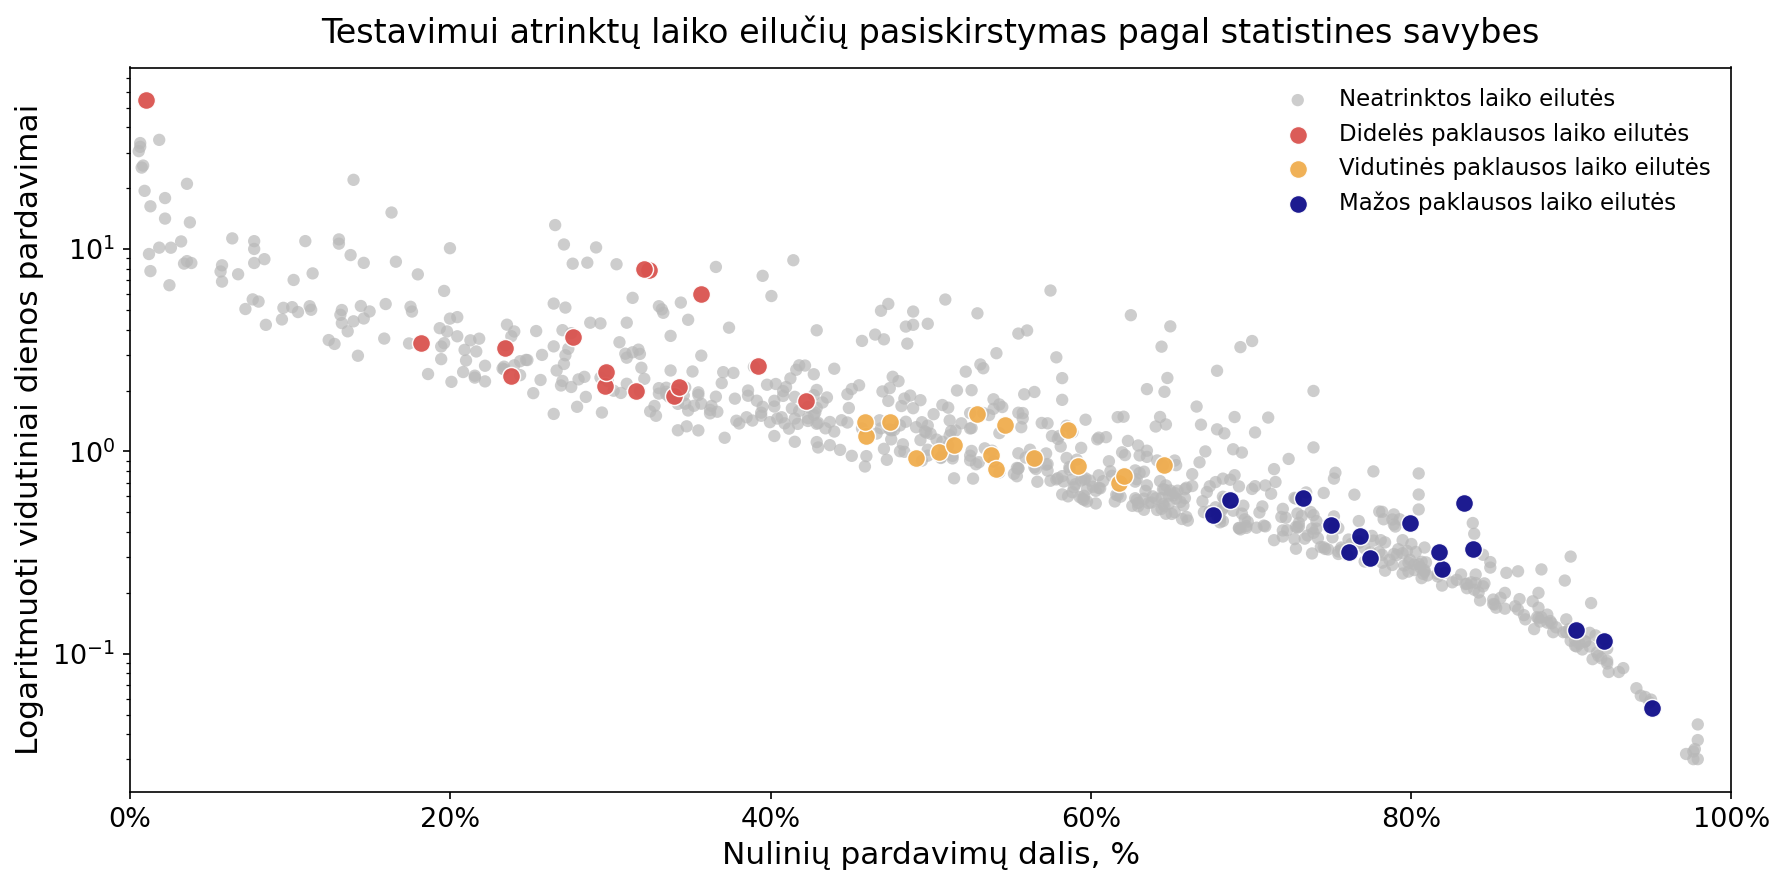

In [6]:
series_stats_plot = series_stats.copy()
series_stats_plot["unique_id"] = (
    series_stats_plot["STORE_ID"].astype(str) + "_" +
    series_stats_plot["SKU_GROUP"].astype(str) + "_" +
    series_stats_plot["SKU_ID"].astype(str)
)
selected_ids = selected_series_metadata["unique_id"].unique()
series_stats_plot["selected"] = series_stats_plot["unique_id"].isin(selected_ids)
series_stats_plot["mean_sales_plot"] = series_stats_plot["mean_sales"].replace(0, np.nan)
plt.figure(figsize=(12, 6), dpi=150)
plt.scatter(
    series_stats_plot.loc[~series_stats_plot["selected"], "zero_pct"],
    series_stats_plot.loc[~series_stats_plot["selected"], "mean_sales_plot"],
    color="#B8B8B8",
    alpha=0.7,
    s=35,
    edgecolors="none",
    label="Neatrinktos laiko eilutės"
)
colors = {
    "high_sales_low_zero_pct": "#D9534F",
    "medium_sales_medium_zero_pct": "#F0AD4E",
    "low_sales_high_zero_pct": "#100E8A"
}
labels_lt = {
    "high_sales_low_zero_pct": "Didelės paklausos laiko eilutės",
    "medium_sales_medium_zero_pct": "Vidutinės paklausos laiko eilutės",
    "low_sales_high_zero_pct": "Mažos paklausos laiko eilutės"
}
for series_type, color in colors.items():
    subset = series_stats_plot[
        (series_stats_plot["selected"]) &
        (series_stats_plot["series_type_2d"].astype(str) == series_type)
    ]
    plt.scatter(
        subset["zero_pct"],
        subset["mean_sales_plot"],
        color=color,
        alpha=0.95,
        s=75,
        edgecolors="white",
        linewidths=0.7,
        label=labels_lt[series_type]
    )
plt.title(
    "Testavimui atrinktų laiko eilučių pasiskirstymas pagal statistines savybes",
    fontsize=16,
    pad=12
)
plt.xlabel("Nulinių pardavimų dalis, %", fontsize=15)
plt.ylabel("Logaritmuoti vidutiniai dienos pardavimai", fontsize=15)
ax = plt.gca()
ax.set_xlim(0, 100)
ax.set_yscale("log")
ax.xaxis.set_major_locator(mtick.MultipleLocator(20))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(frameon=False, fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

Sudaroma atrinktų paklausos tipų suvestinė.


In [7]:
target_type_labels = {
    "high_sales_low_zero_pct": "Dideli pardavimai, maža nulinių pardavimų dalis",
    "medium_sales_medium_zero_pct": "Vidutiniai pardavimai, vidutinė nulinių pardavimų dalis",
    "low_sales_high_zero_pct": "Maži pardavimai, didelė nulinių pardavimų dalis"
}

all_type_counts = (
    series_stats[series_stats["series_type_2d"].isin(target_types_2d)]
    .groupby("series_type_2d")
    .size()
    .reindex(target_types_2d)
    .reset_index(name="Visų laiko eilučių skaičius")
)

selected_type_counts = (
    selected_series_metadata
    .groupby("series_type_2d")
    .size()
    .reindex(target_types_2d)
    .reset_index(name="Atrinktų laiko eilučių skaičius")
)

selection_count_table = all_type_counts.merge(
    selected_type_counts,
    on="series_type_2d",
    how="left"
)

selection_count_table["Paklausos tipas"] = (
    selection_count_table["series_type_2d"].map(target_type_labels)
)

selection_count_table = selection_count_table[
    [
        "Paklausos tipas",
        "Visų laiko eilučių skaičius",
        "Atrinktų laiko eilučių skaičius"
    ]
]

display(selection_count_table)

,Paklausos tipas,Visų laiko eilučių skaičius,Atrinktų laiko eilučių skaičius
0,"Dideli pardavimai, maža nulinių pardavimų dalis",217,15
1,"Maži pardavimai, didelė nulinių pardavimų dalis",230,15
2,"Vidutiniai pardavimai, vidutinė nulinių pardav...",182,16


Braižomi atrinktų eilučių ACF ir PACF grafikai.


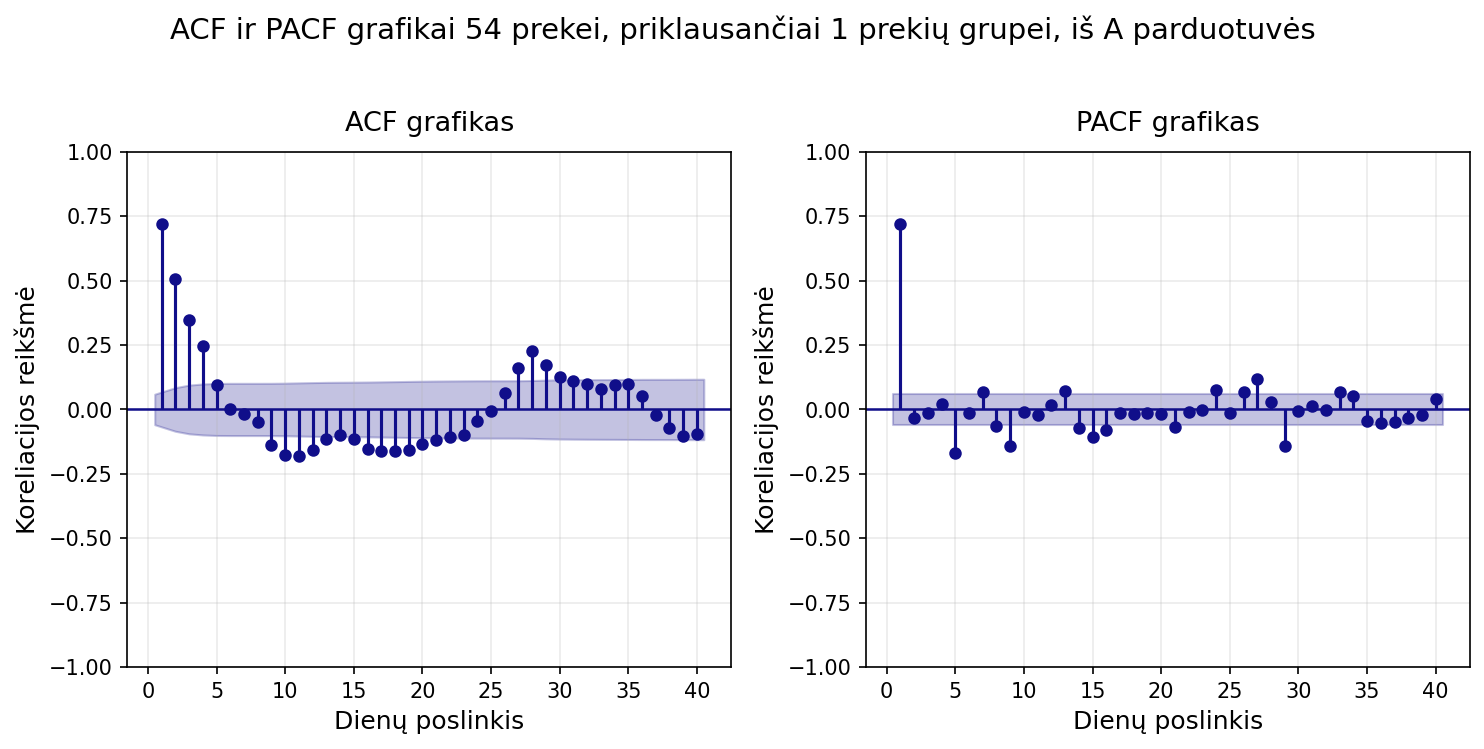

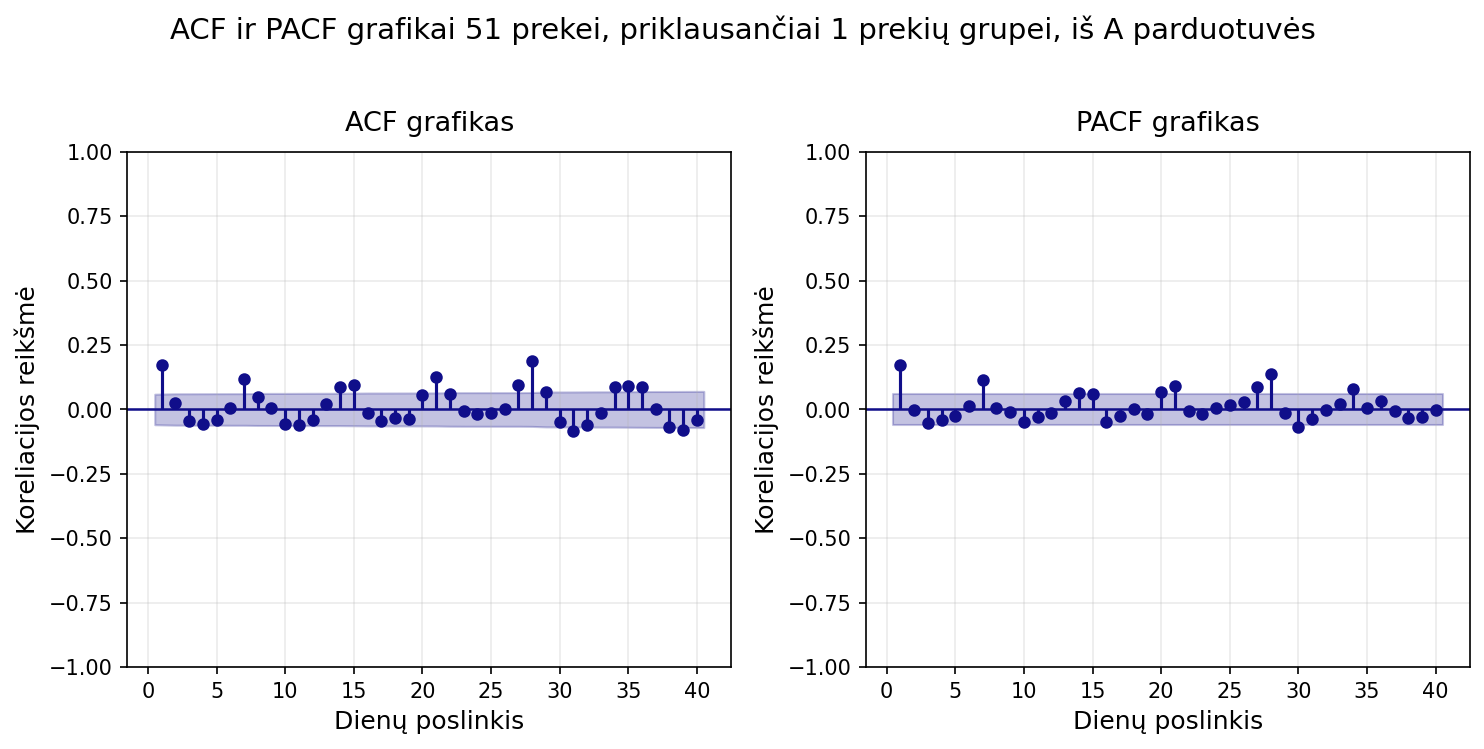

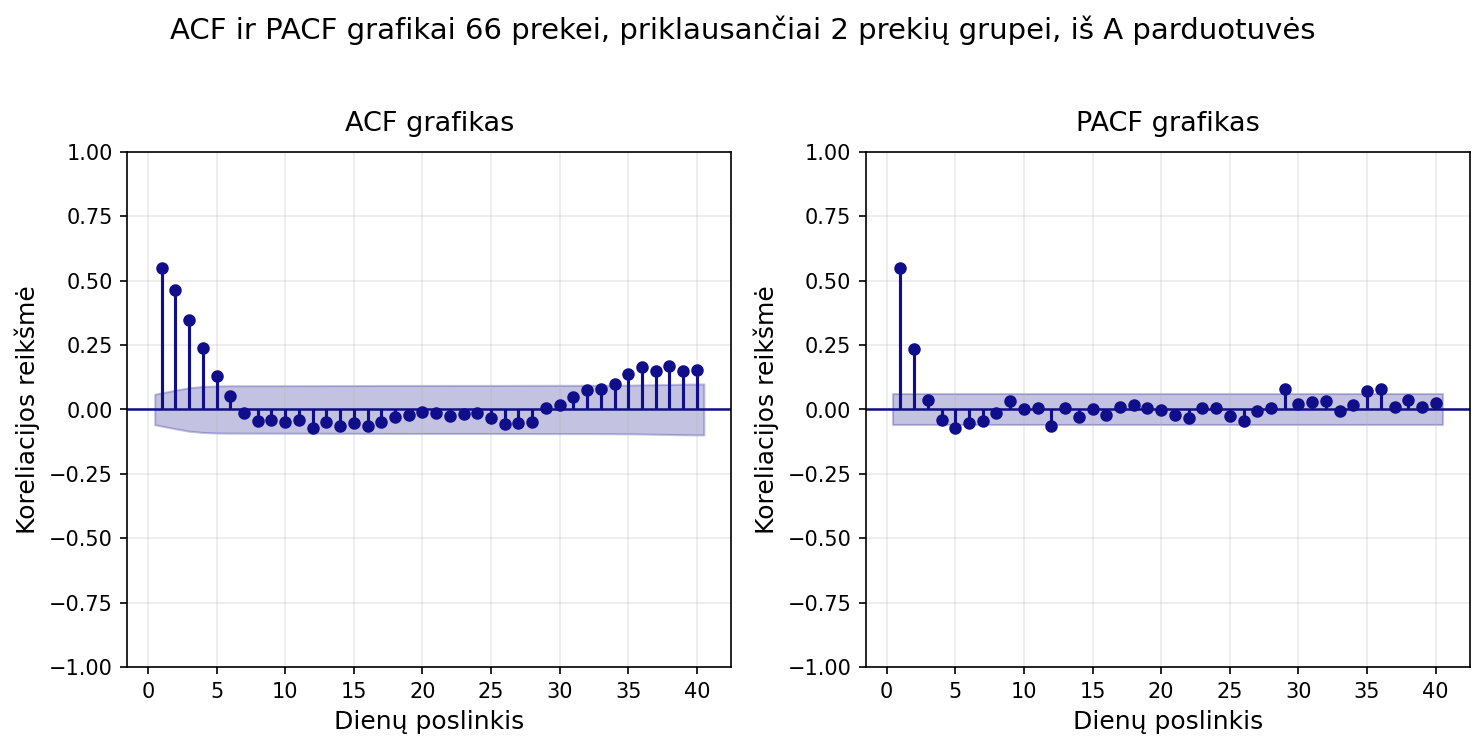

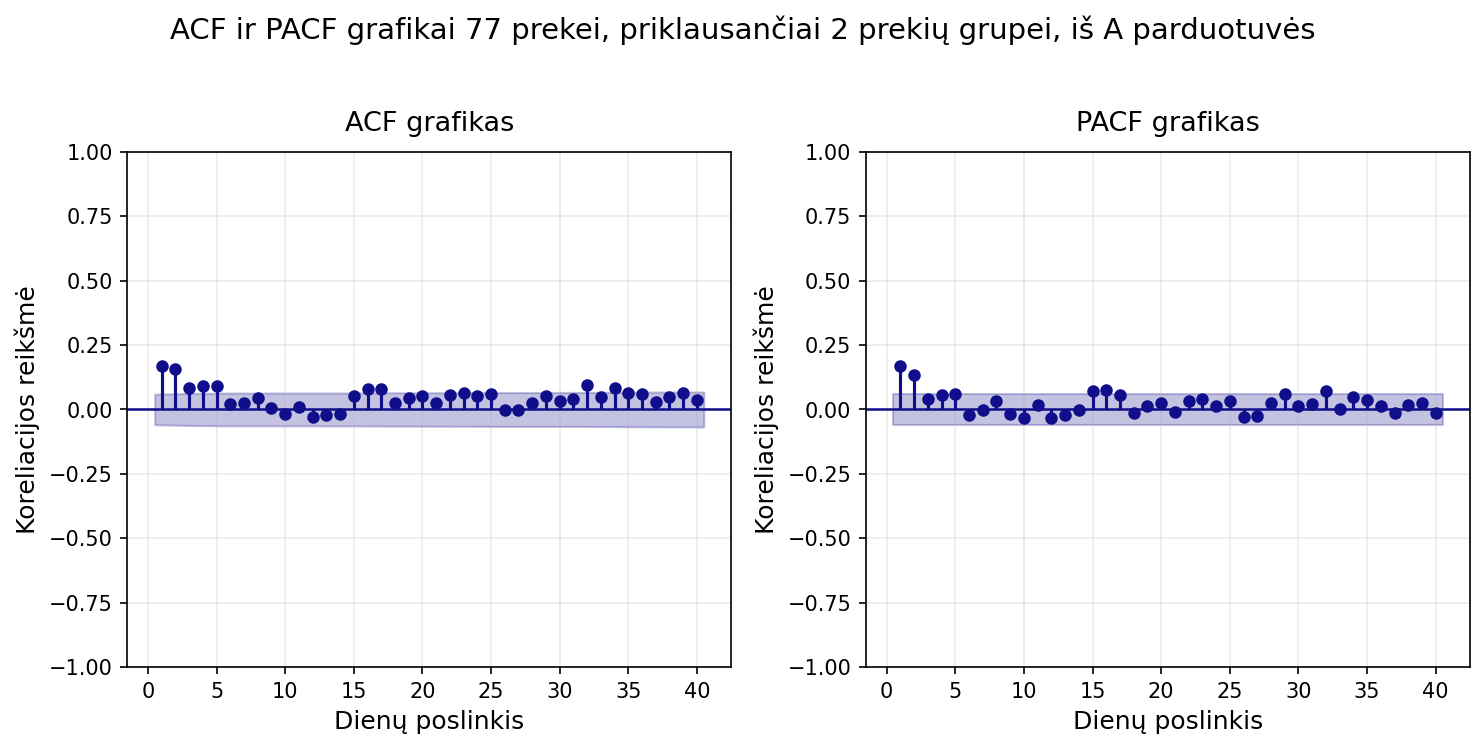

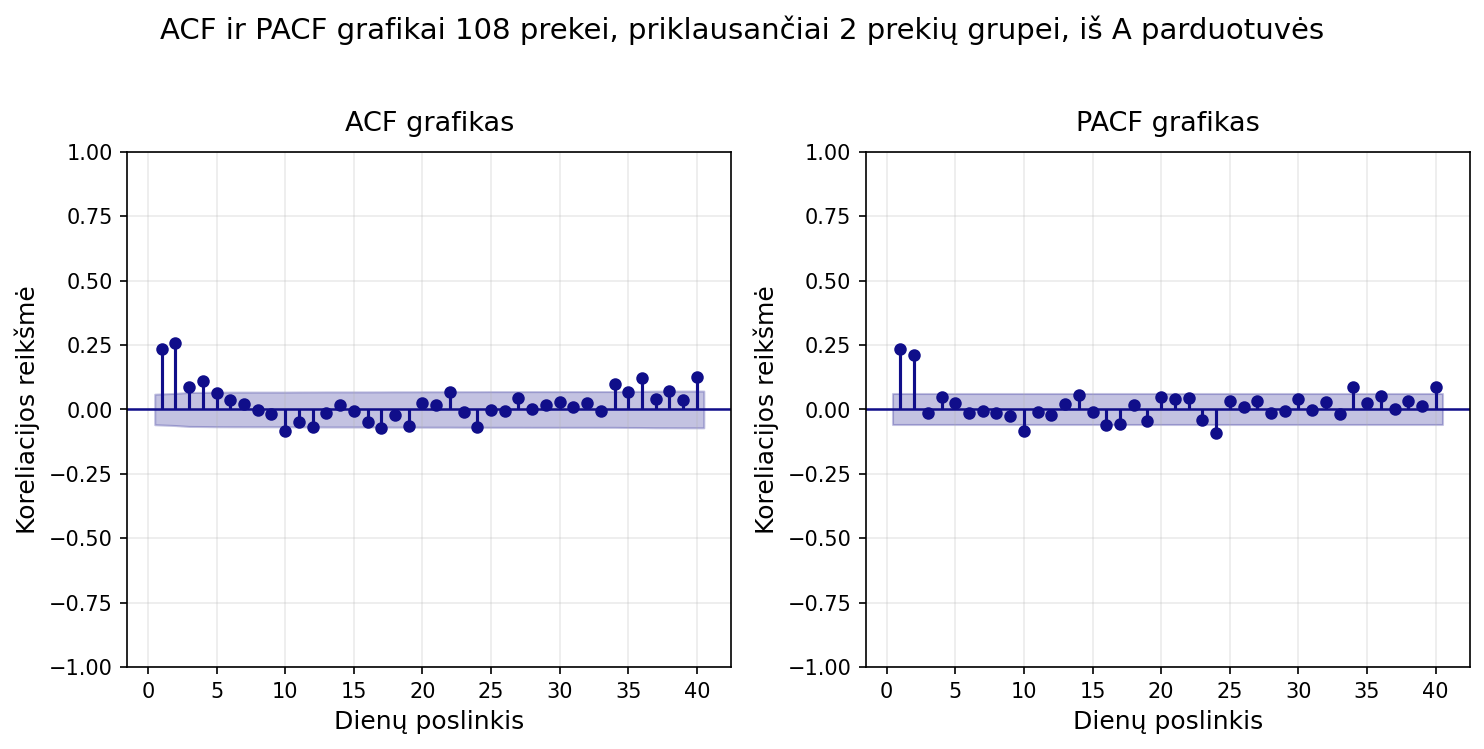

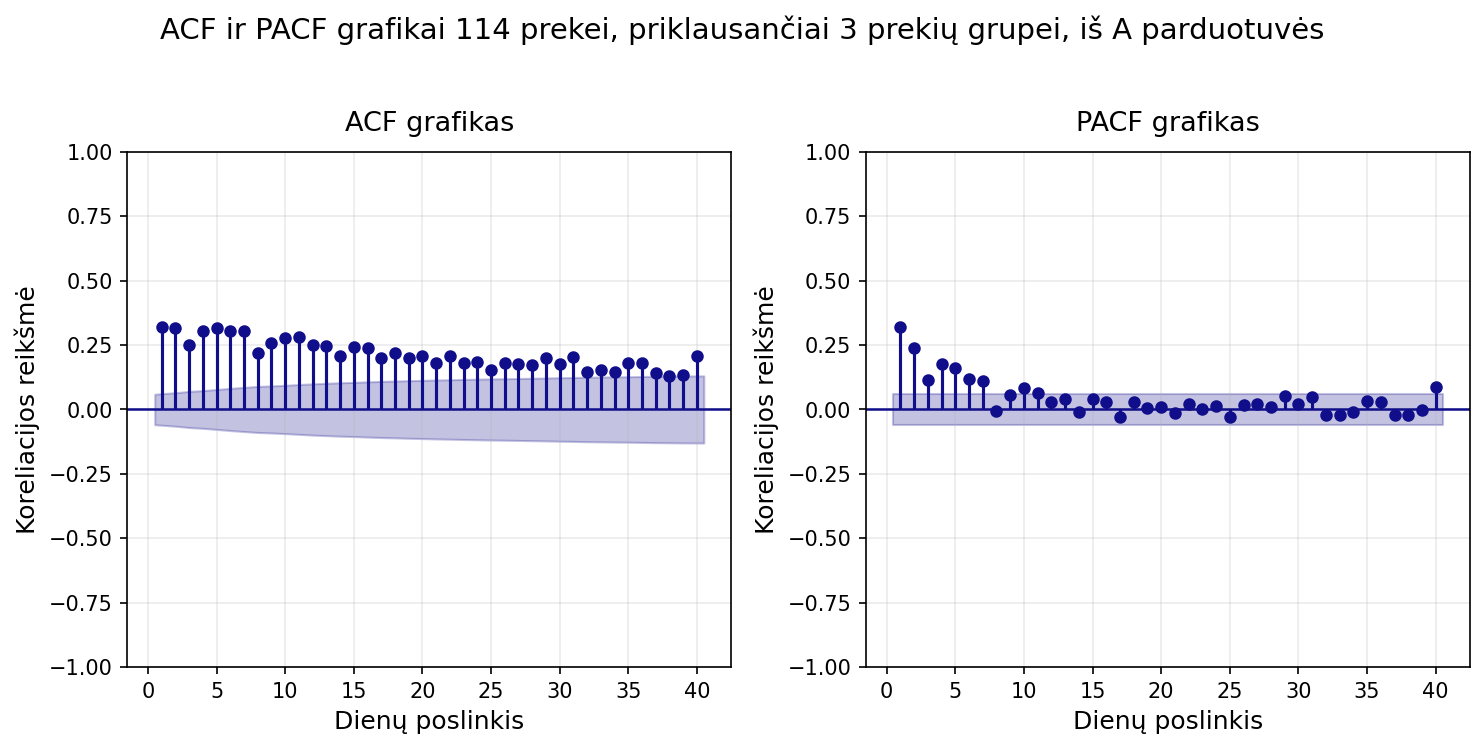

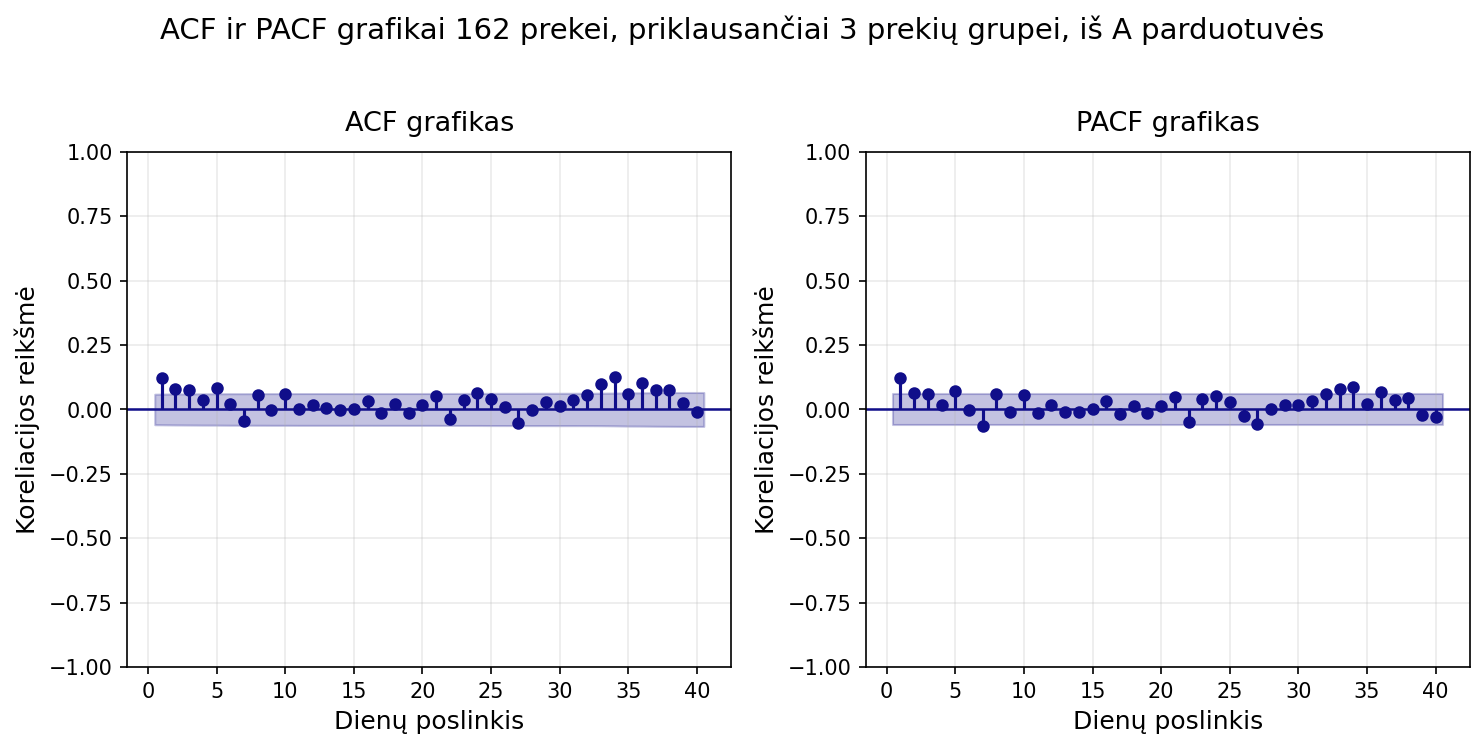

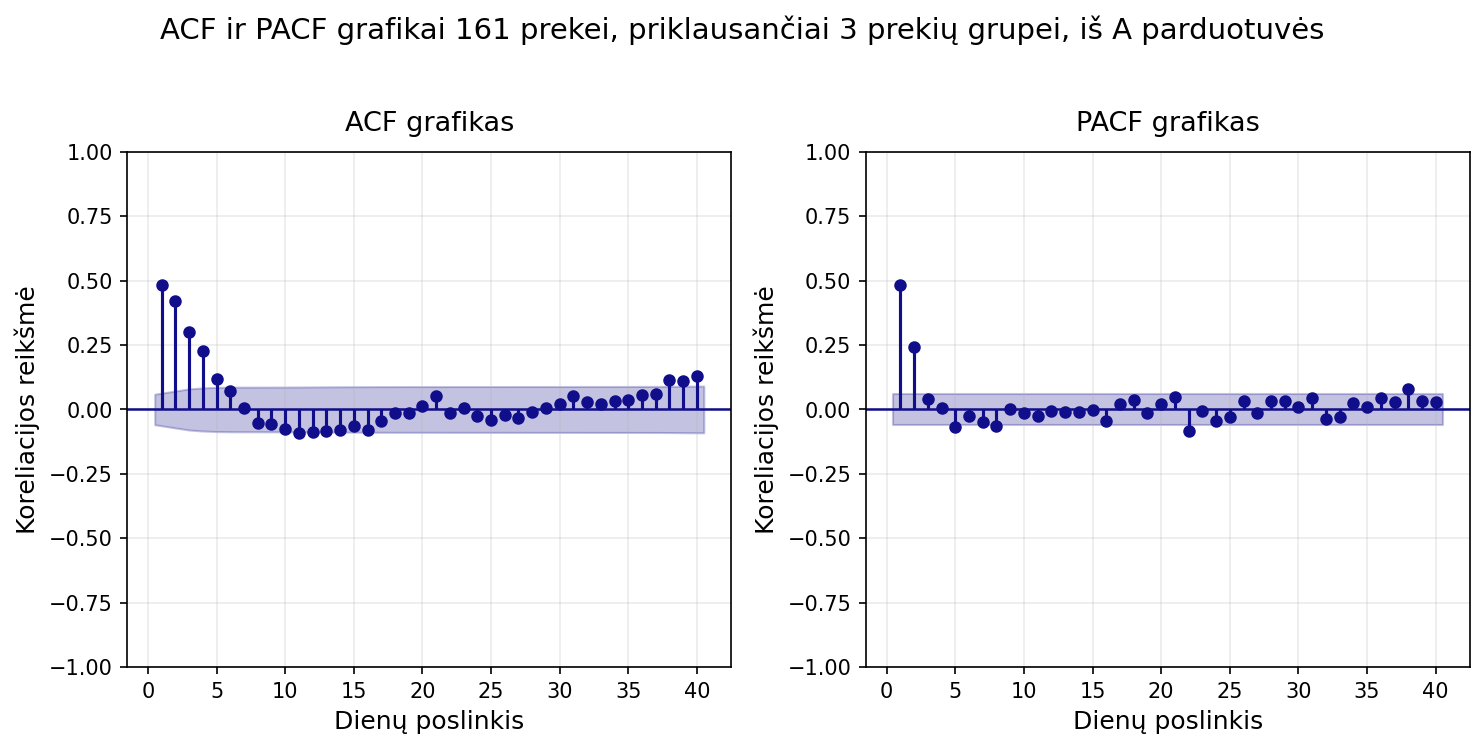

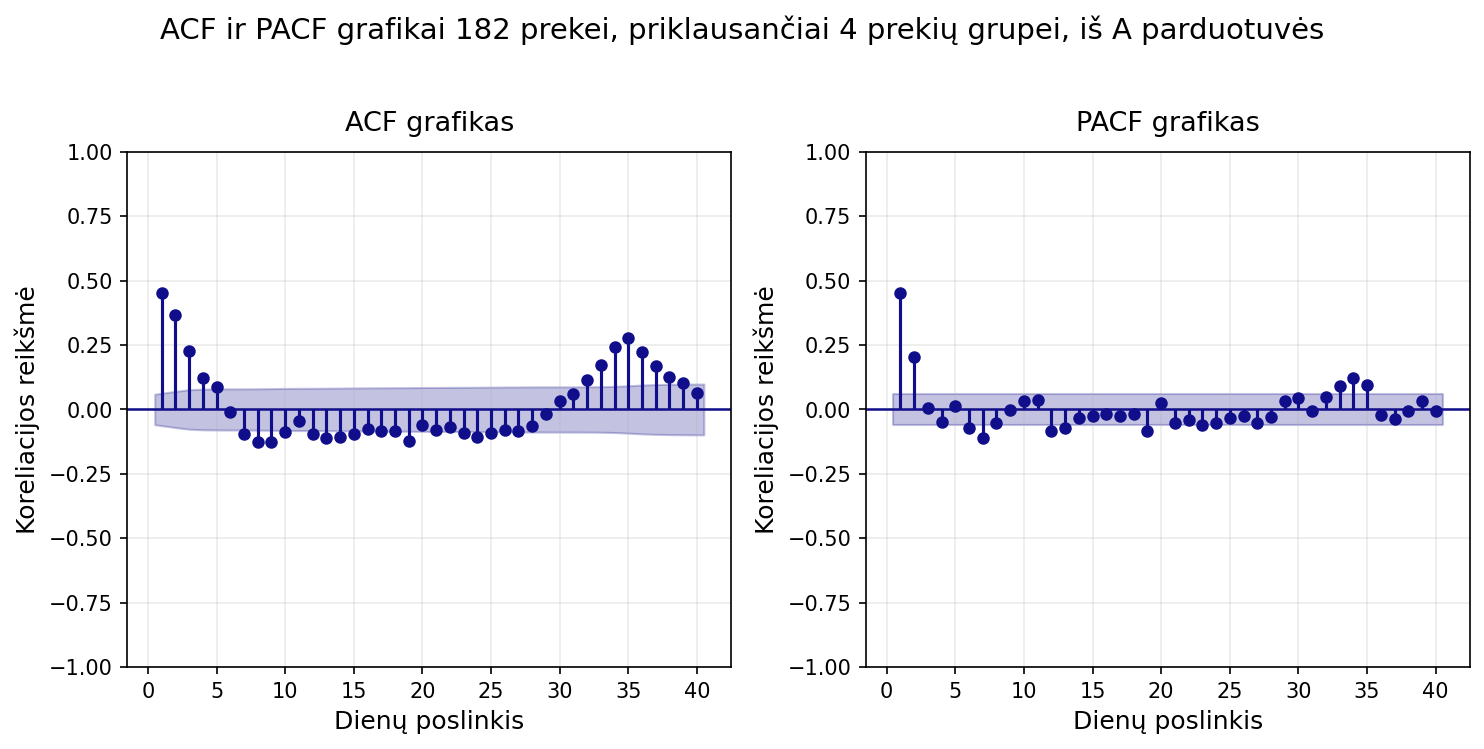

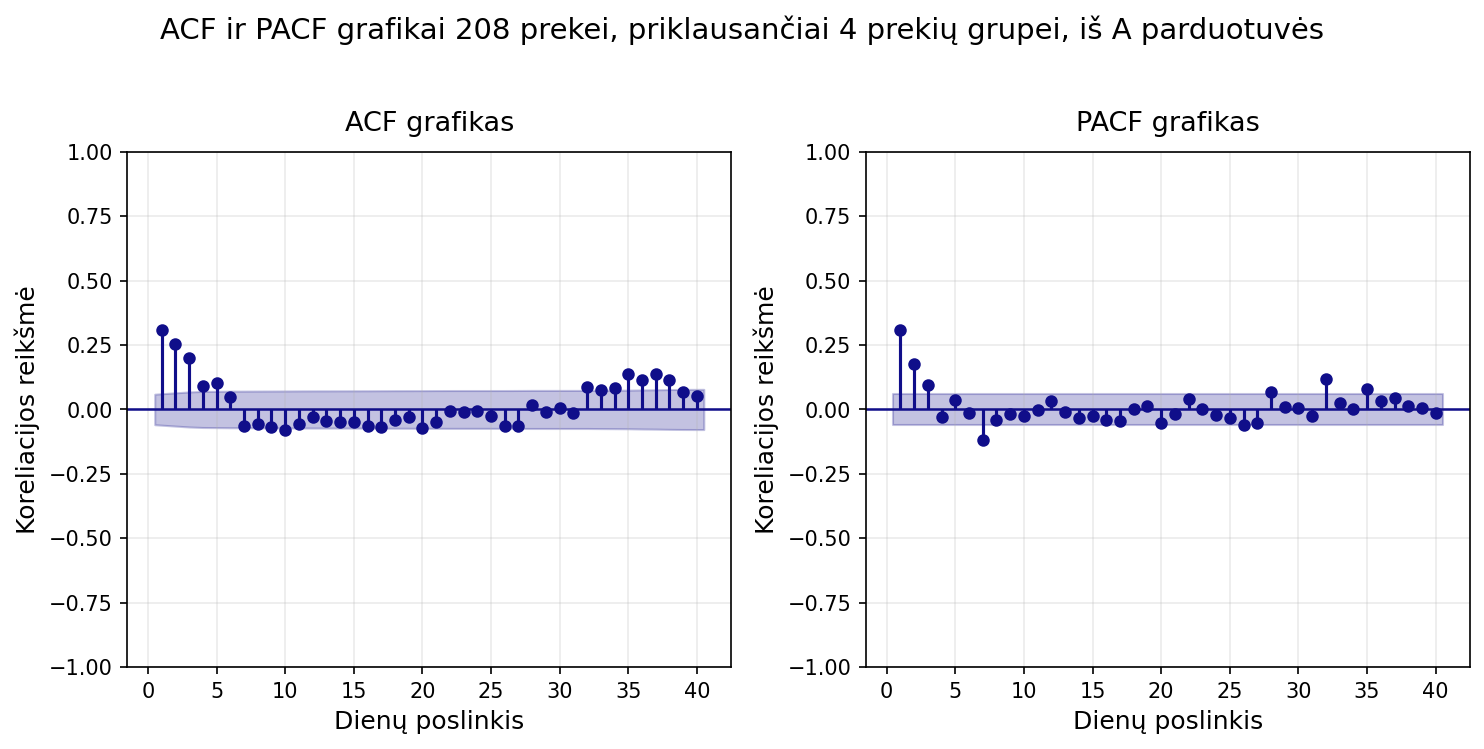

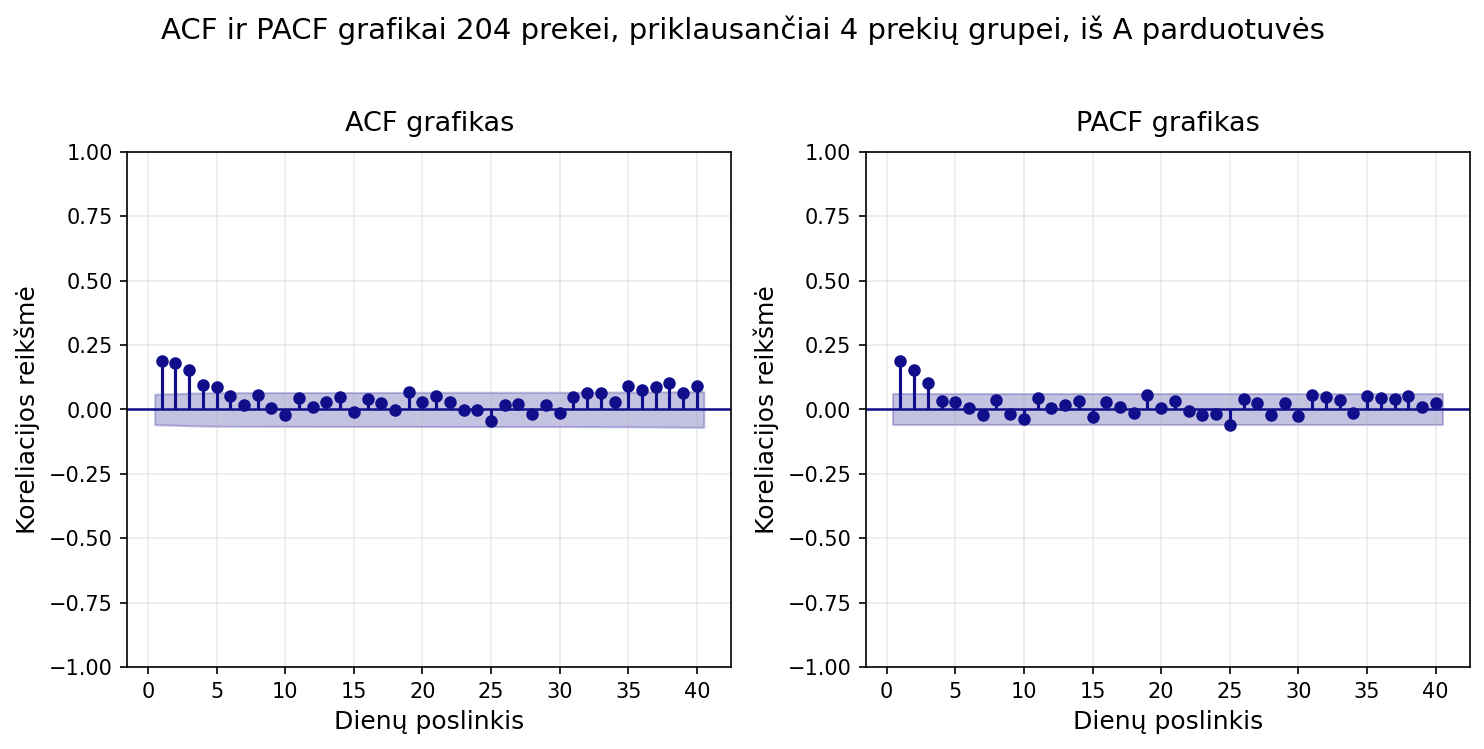

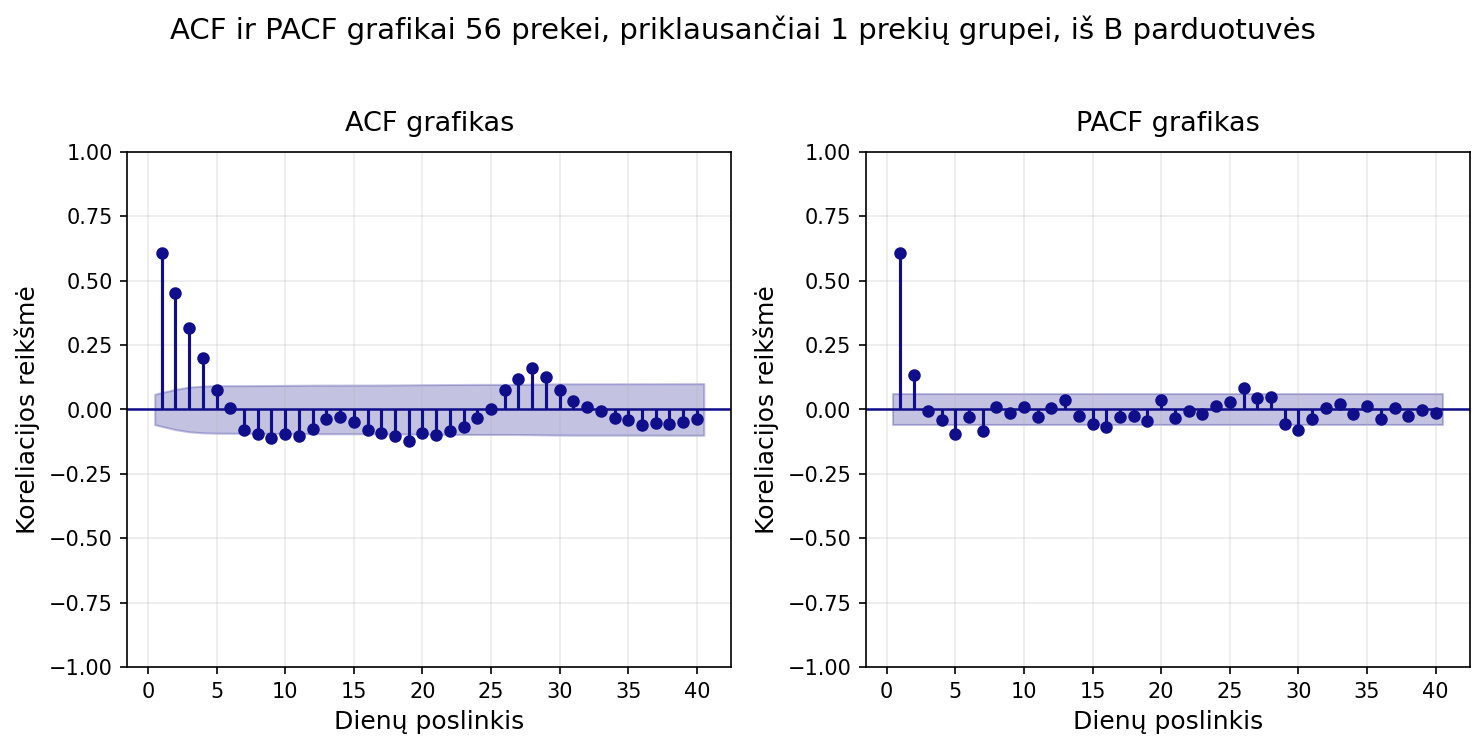

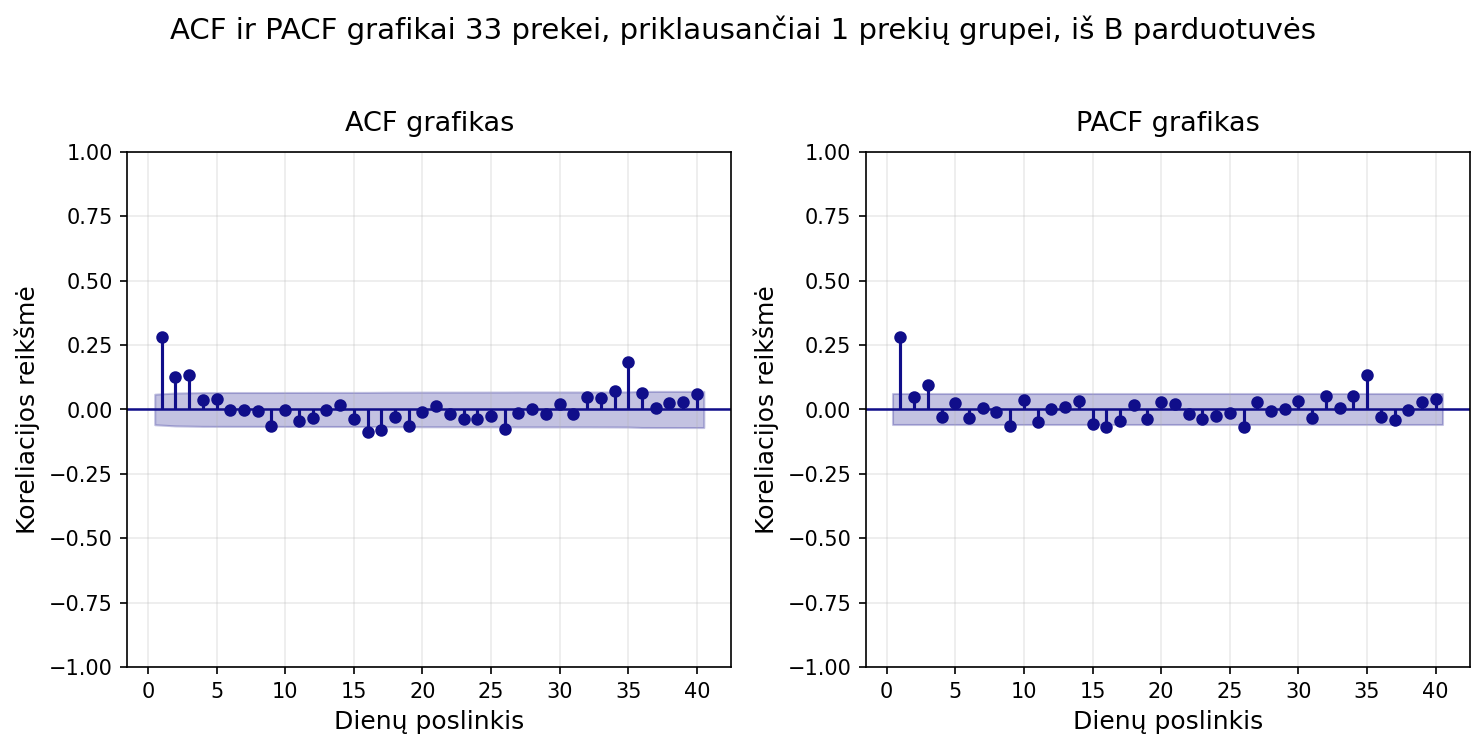

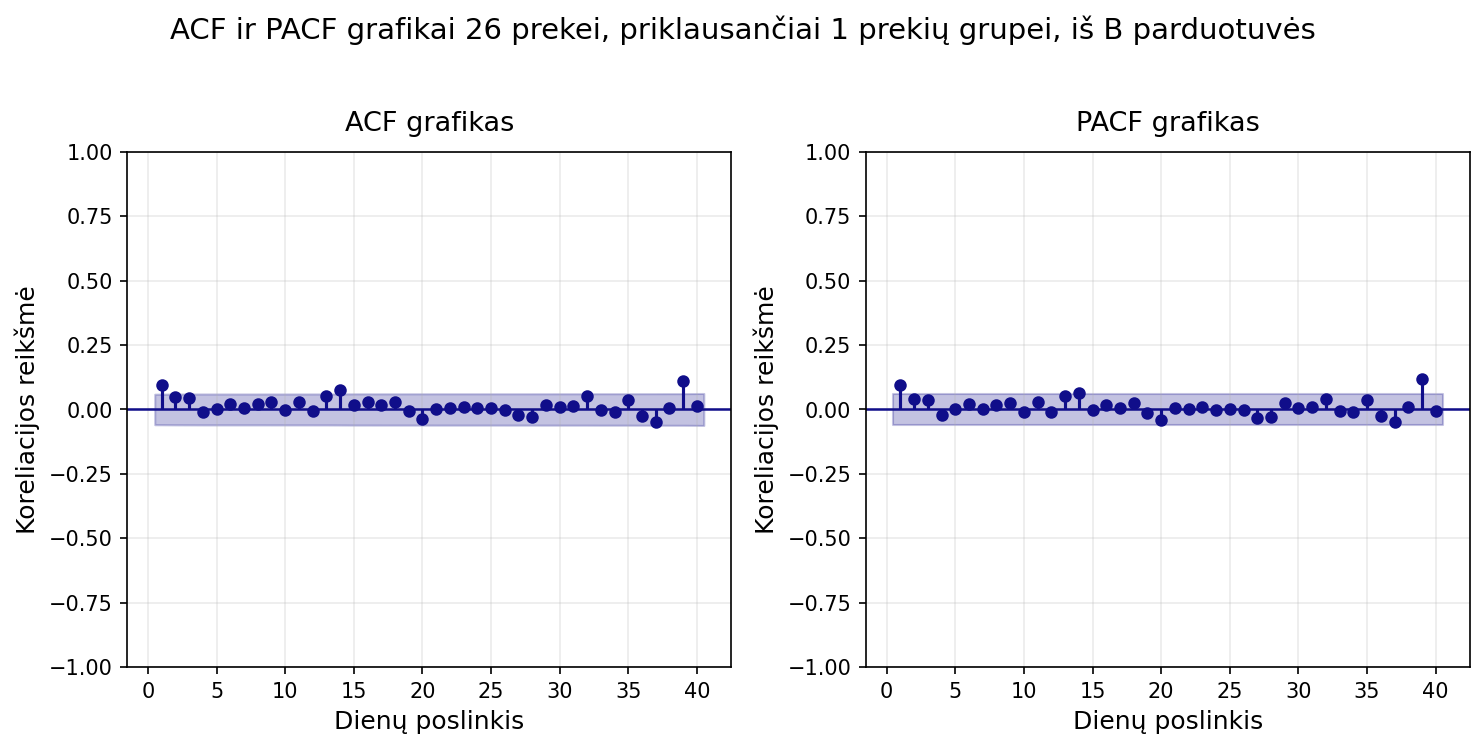

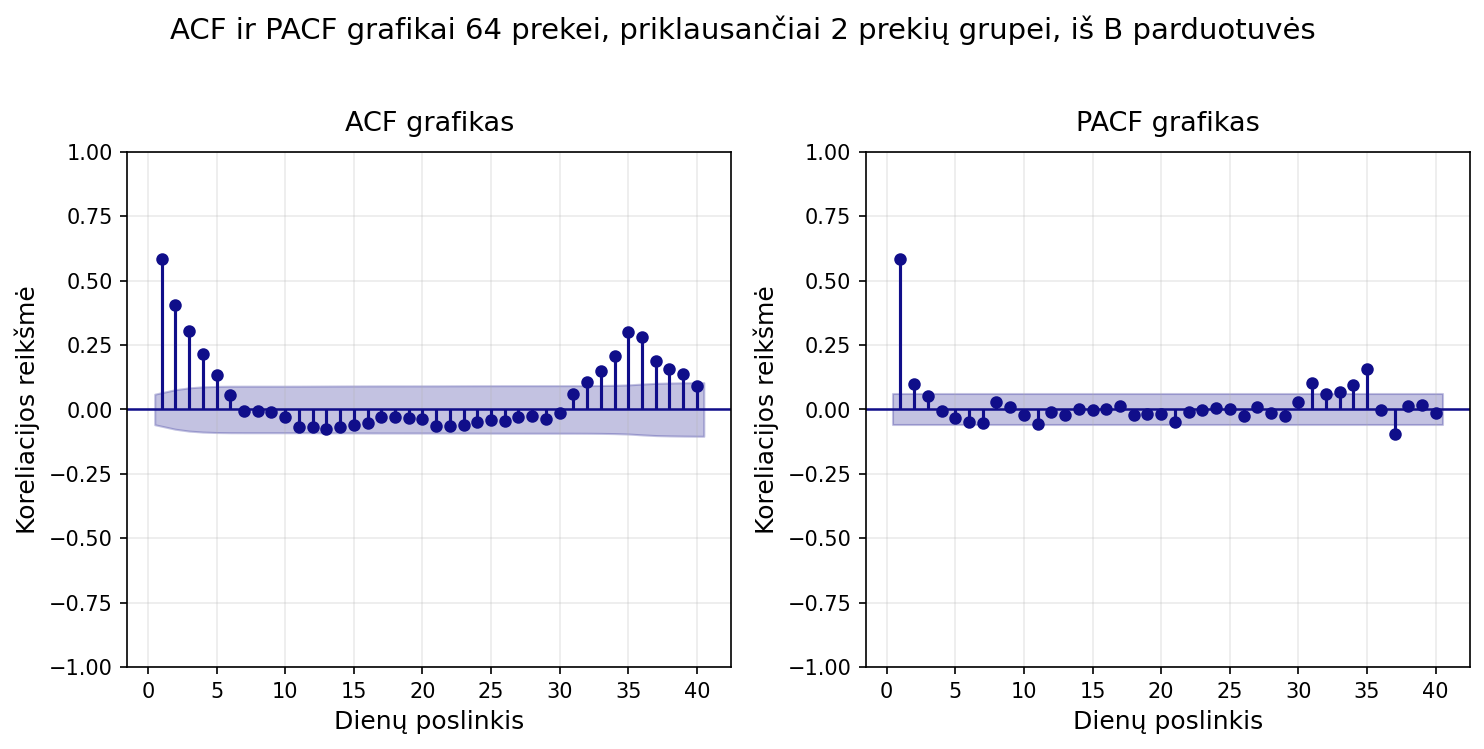

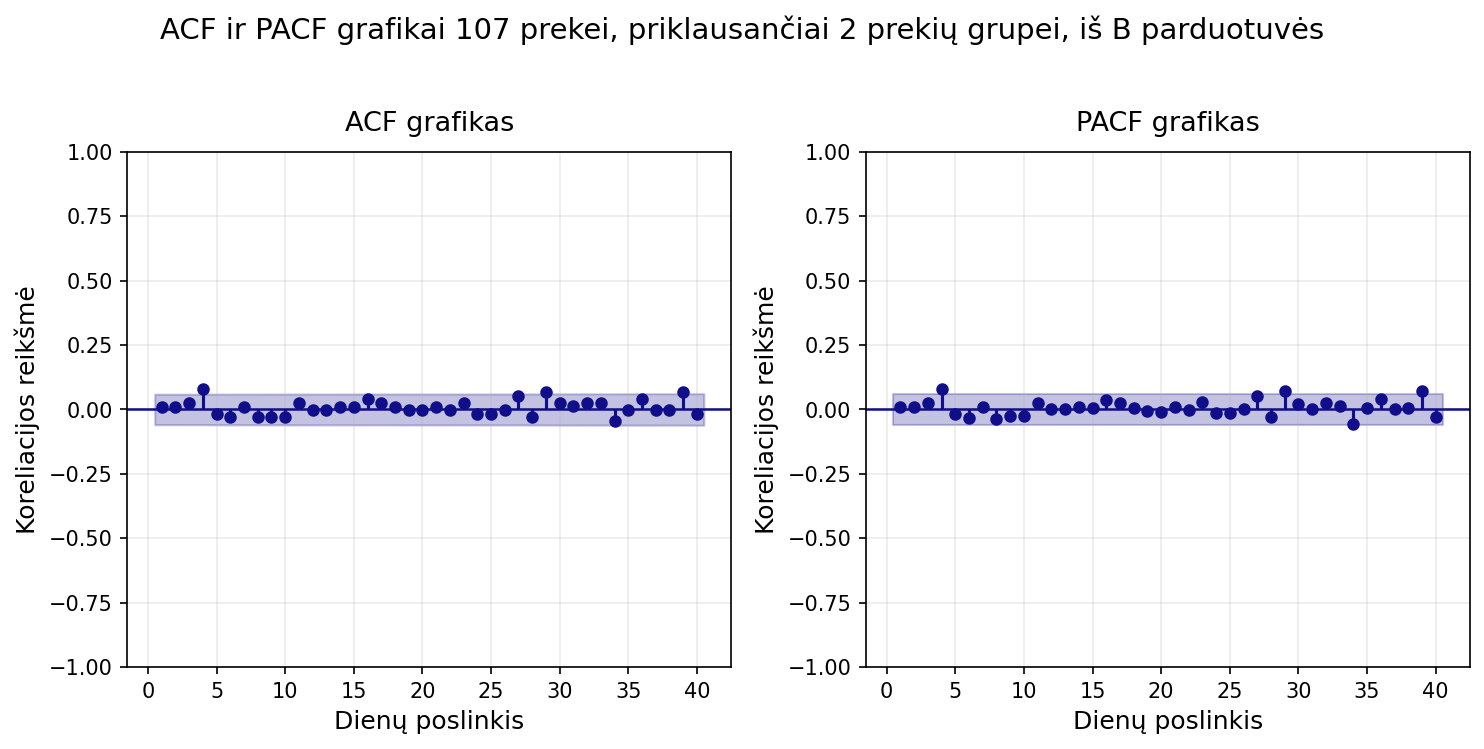

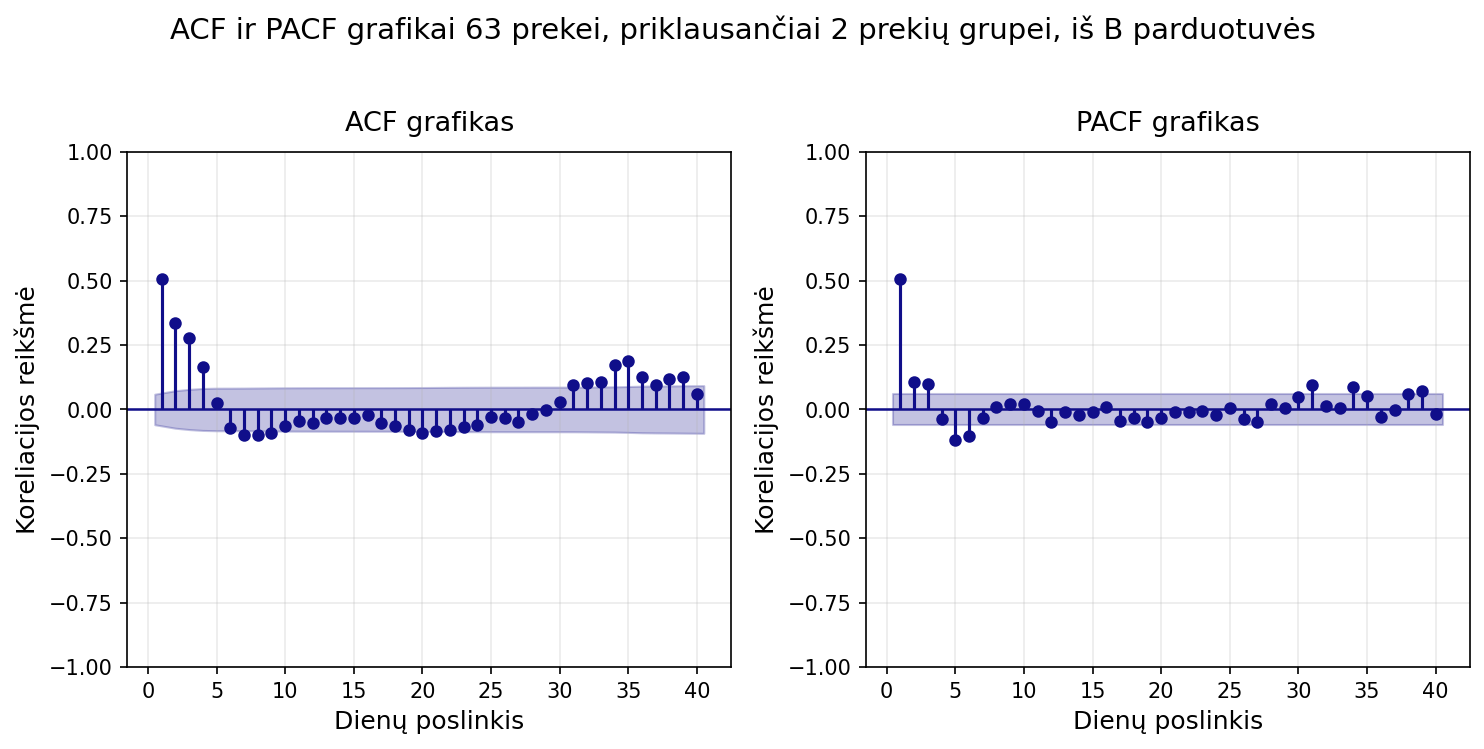

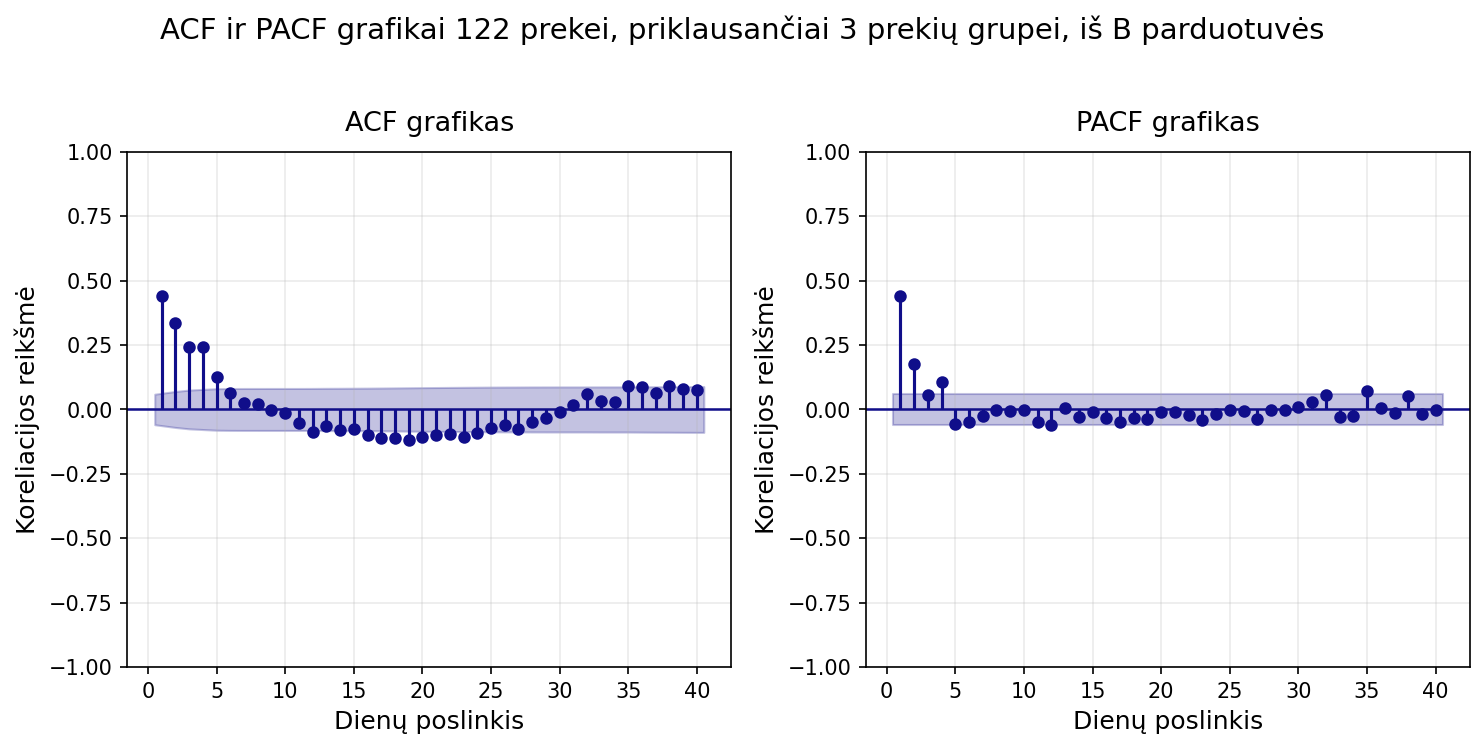

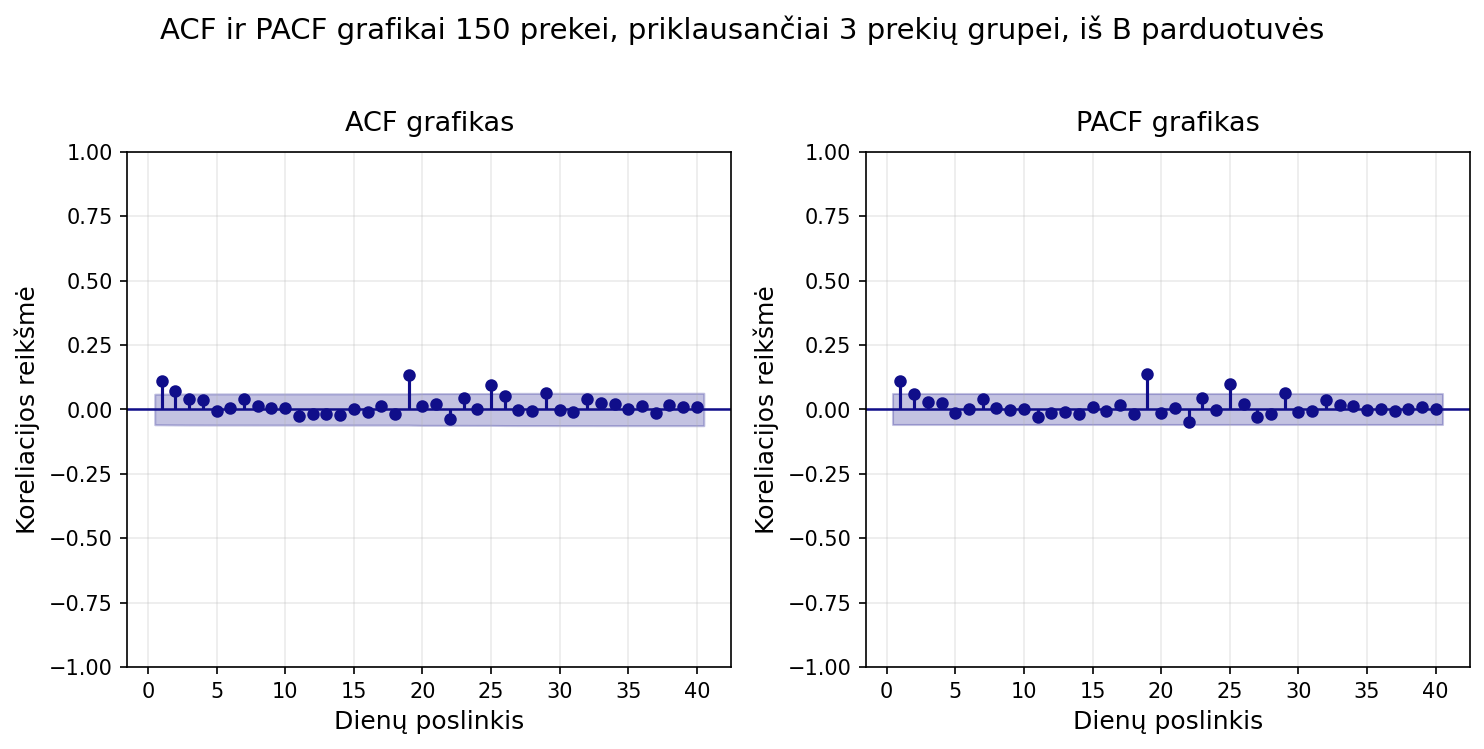

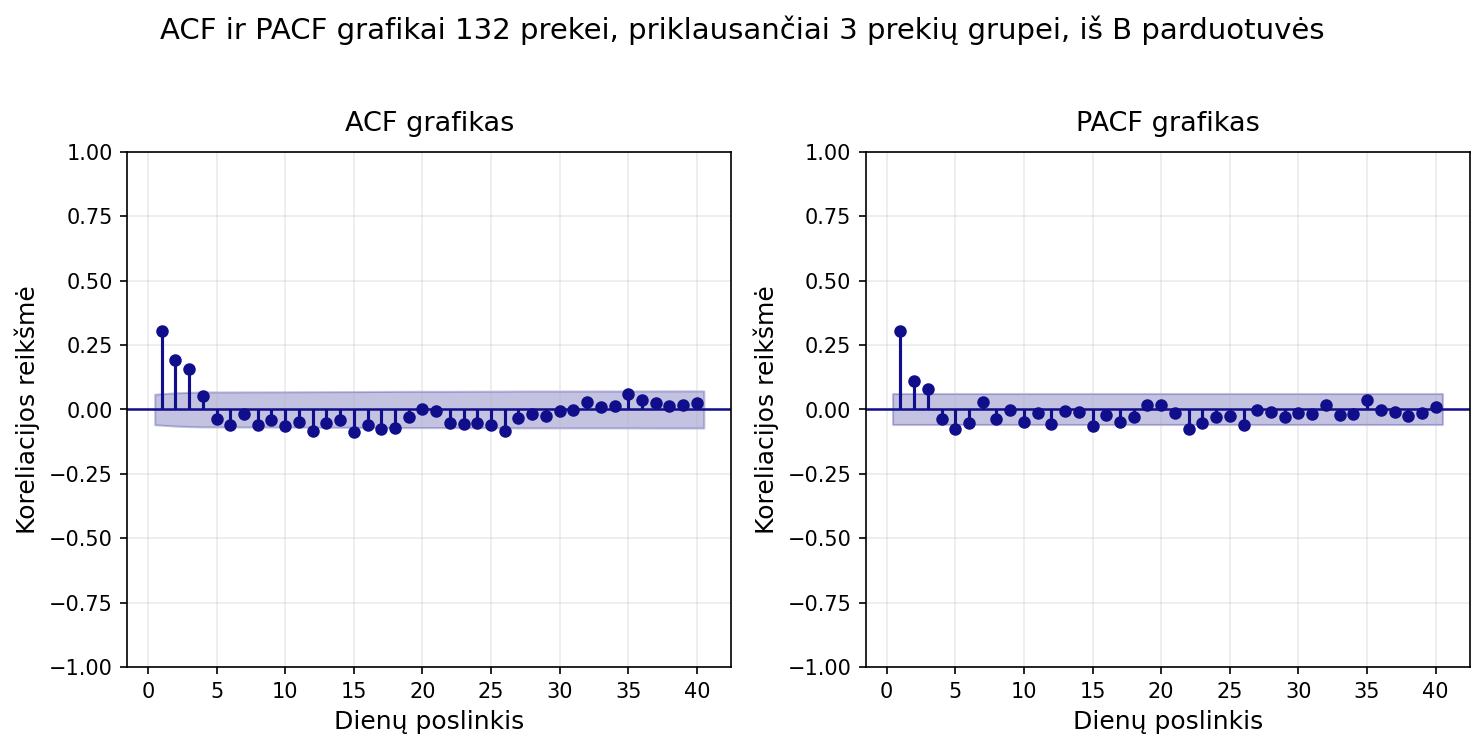

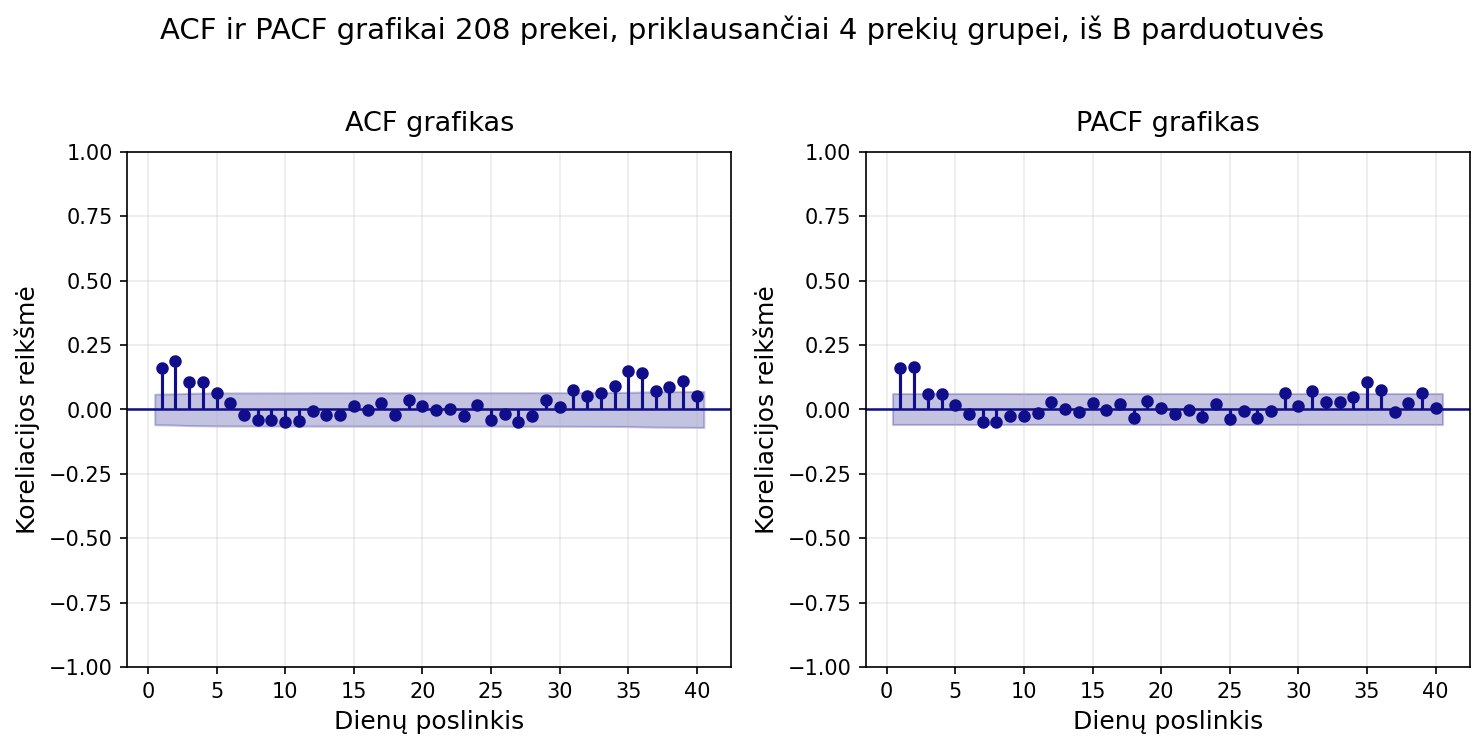

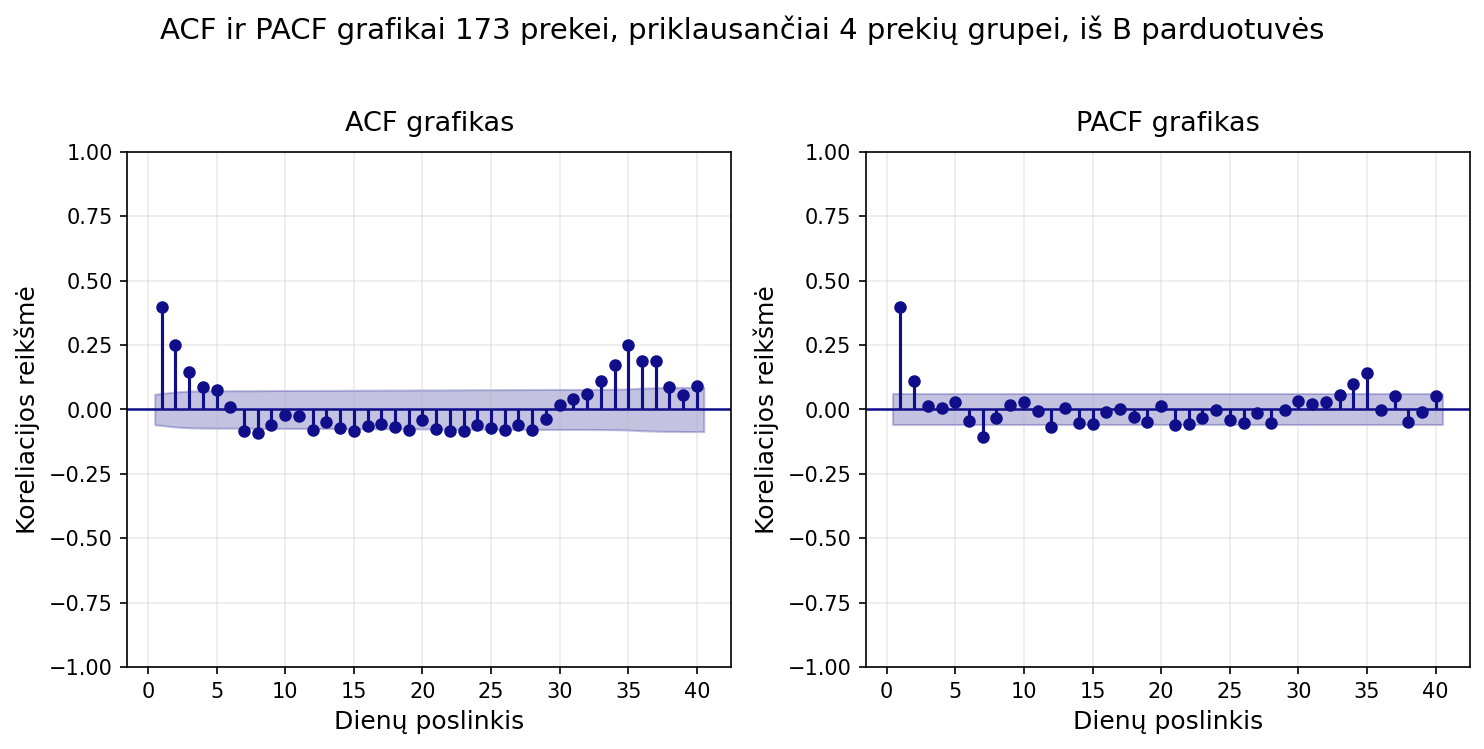

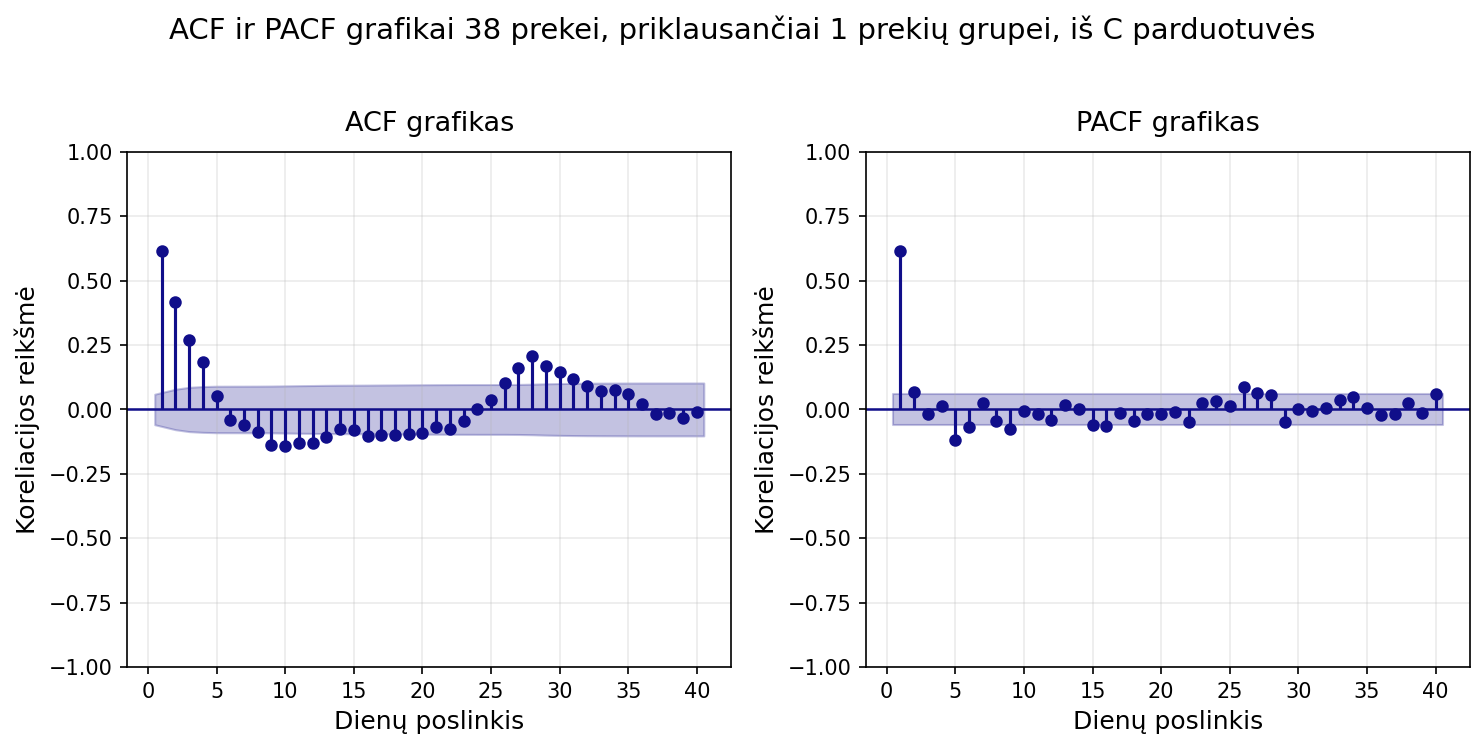

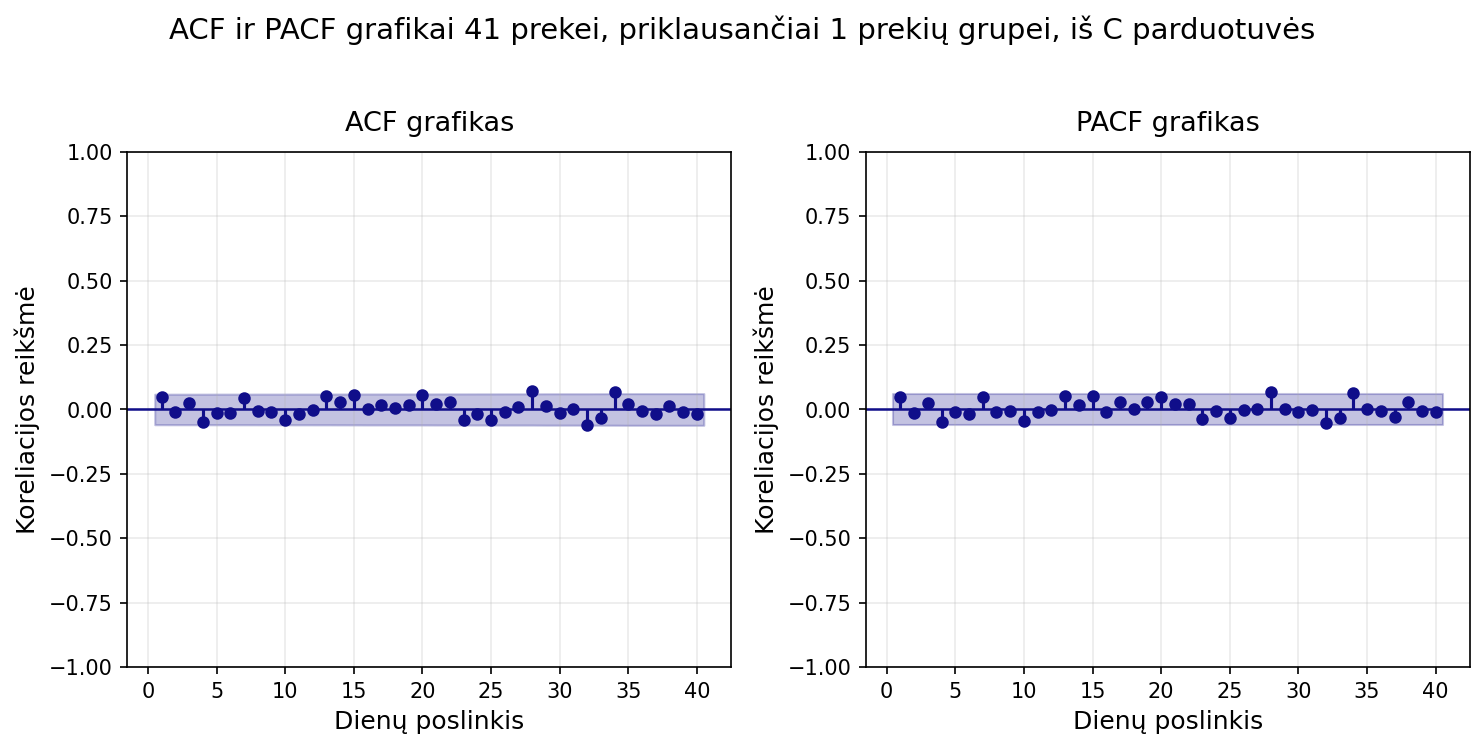

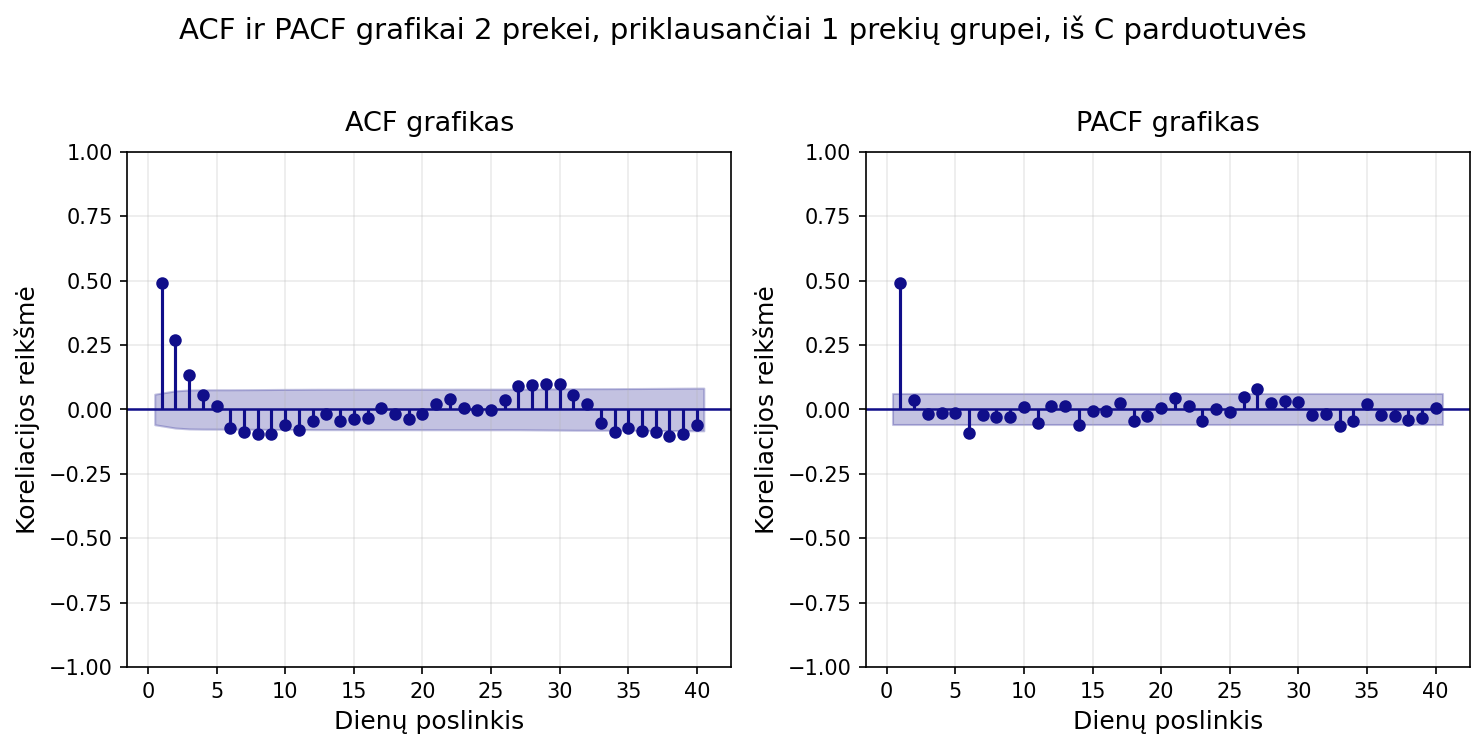

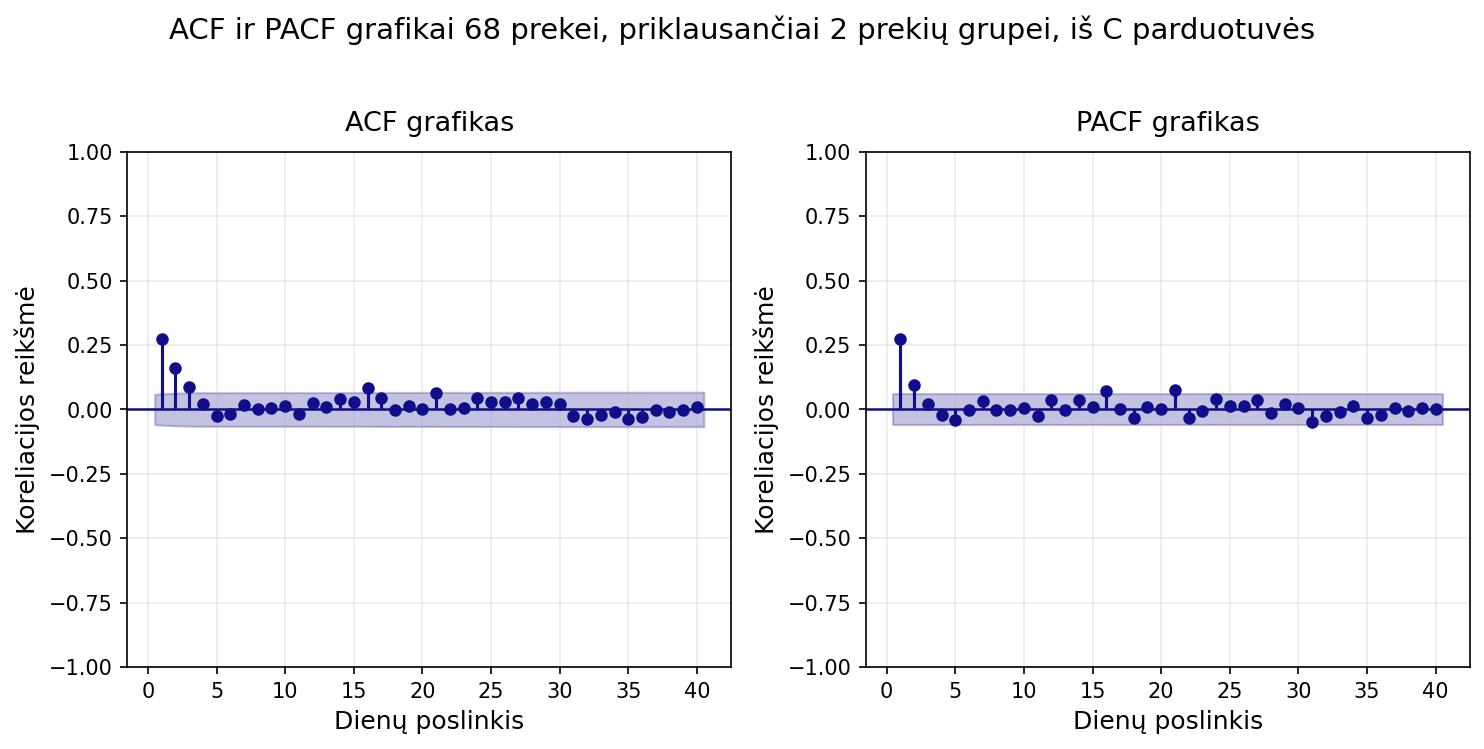

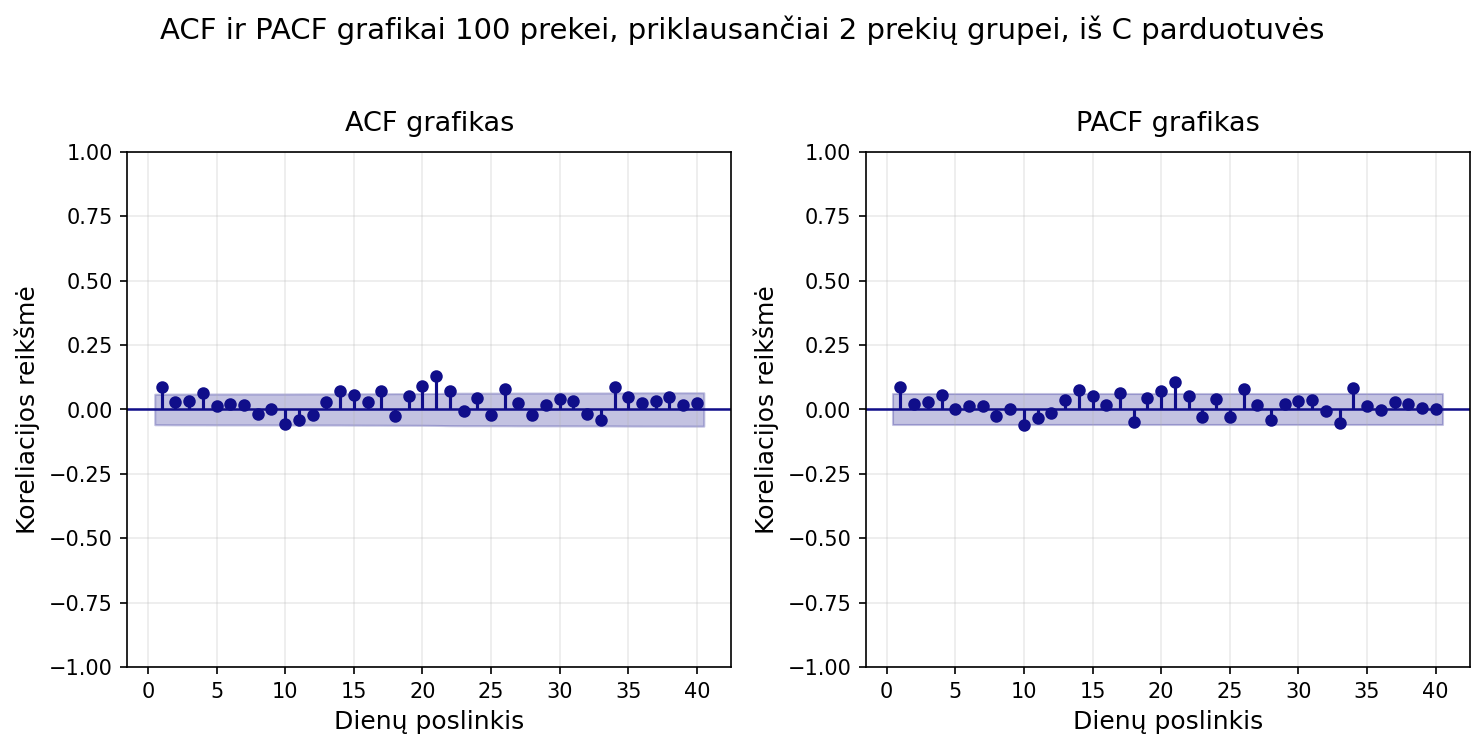

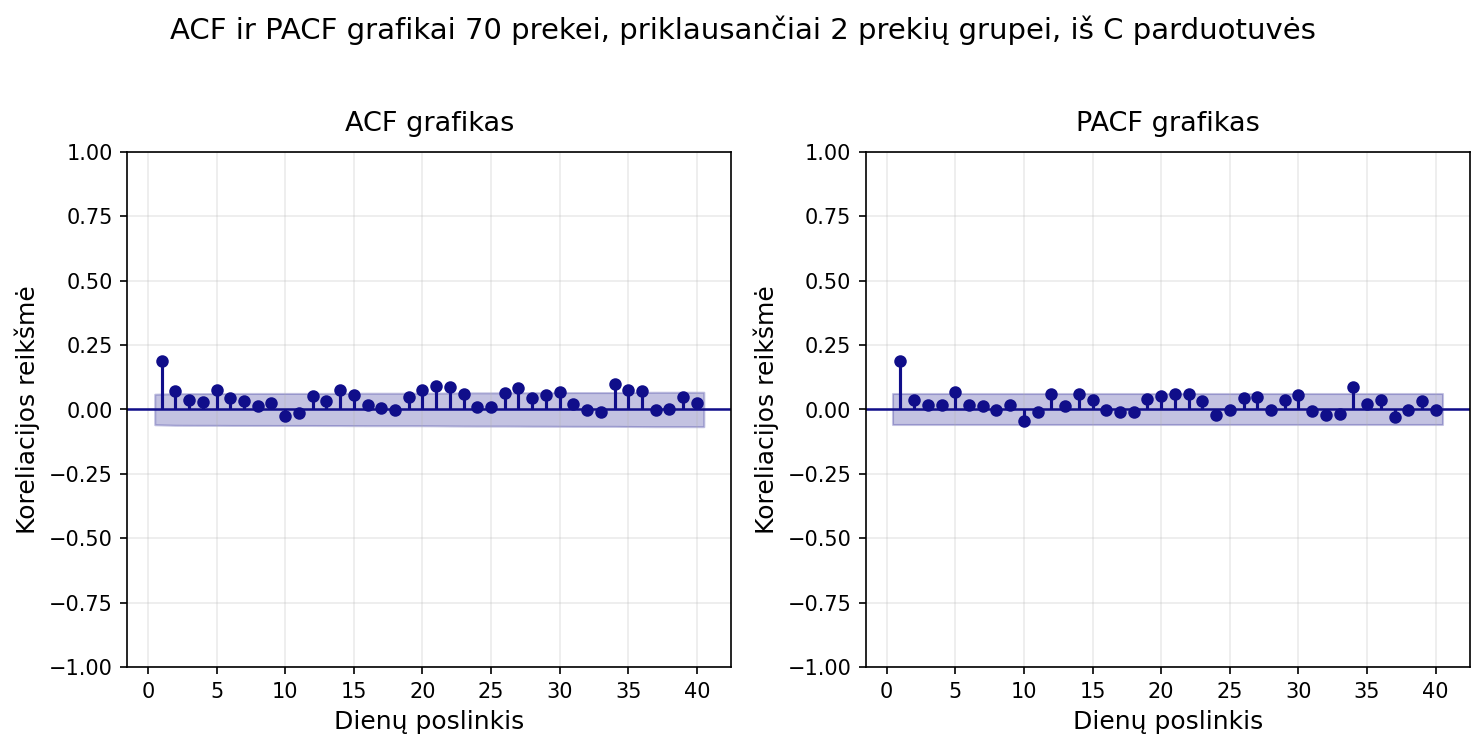

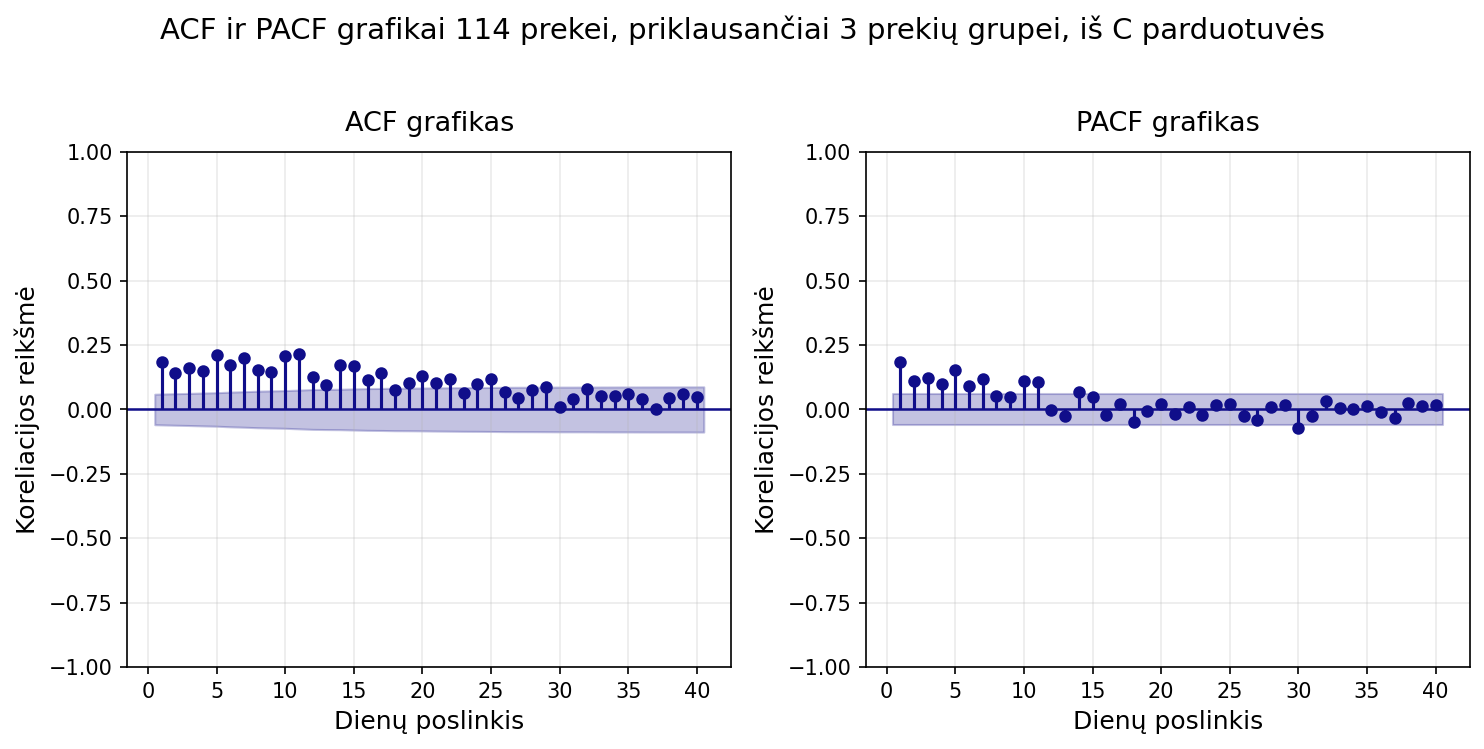

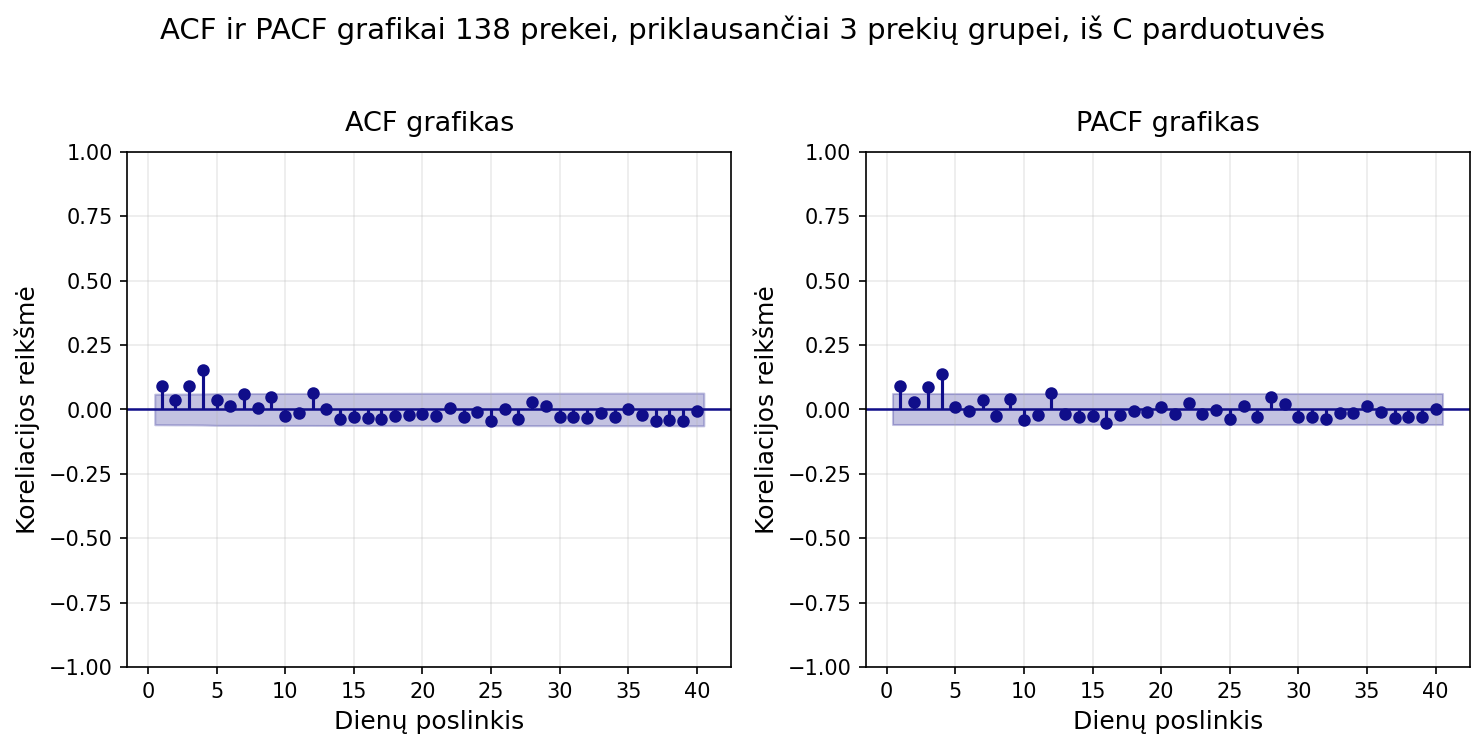

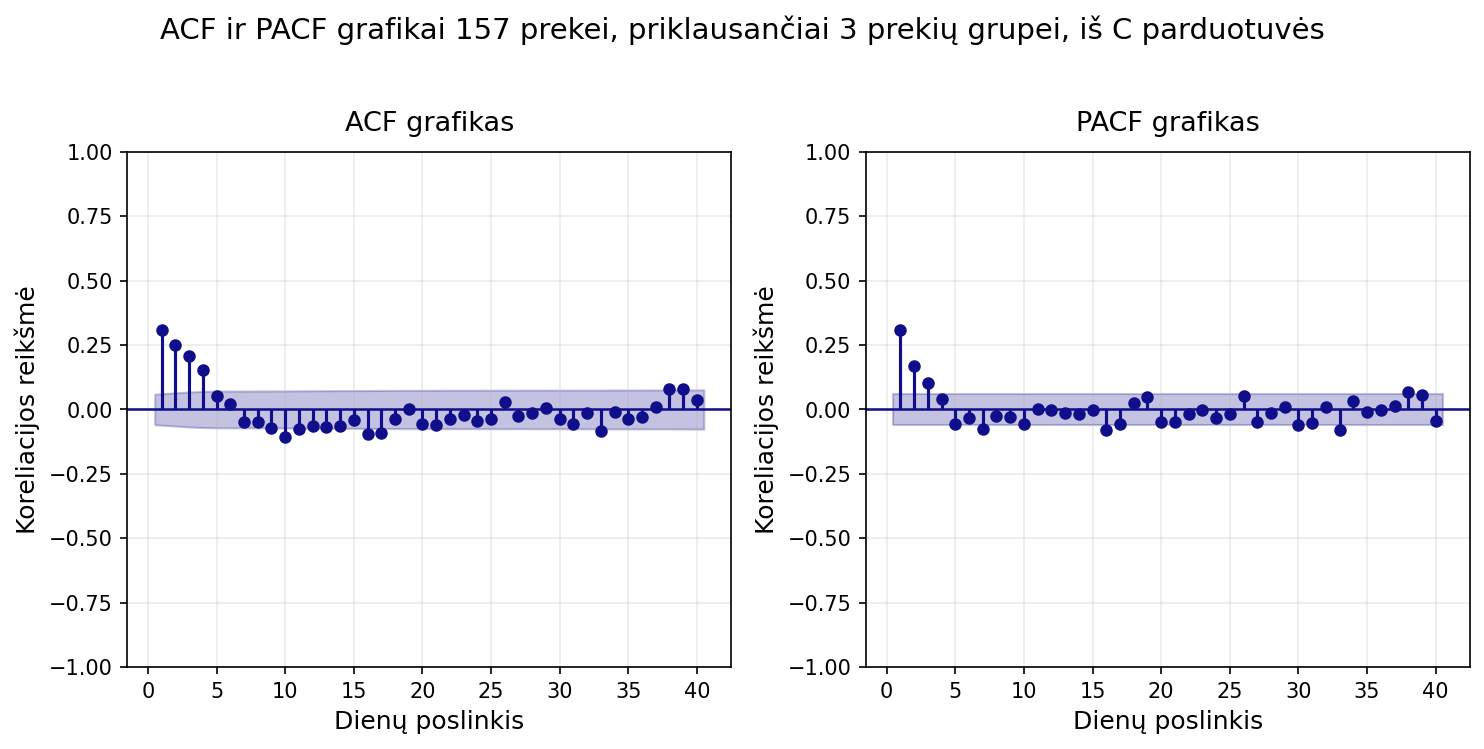

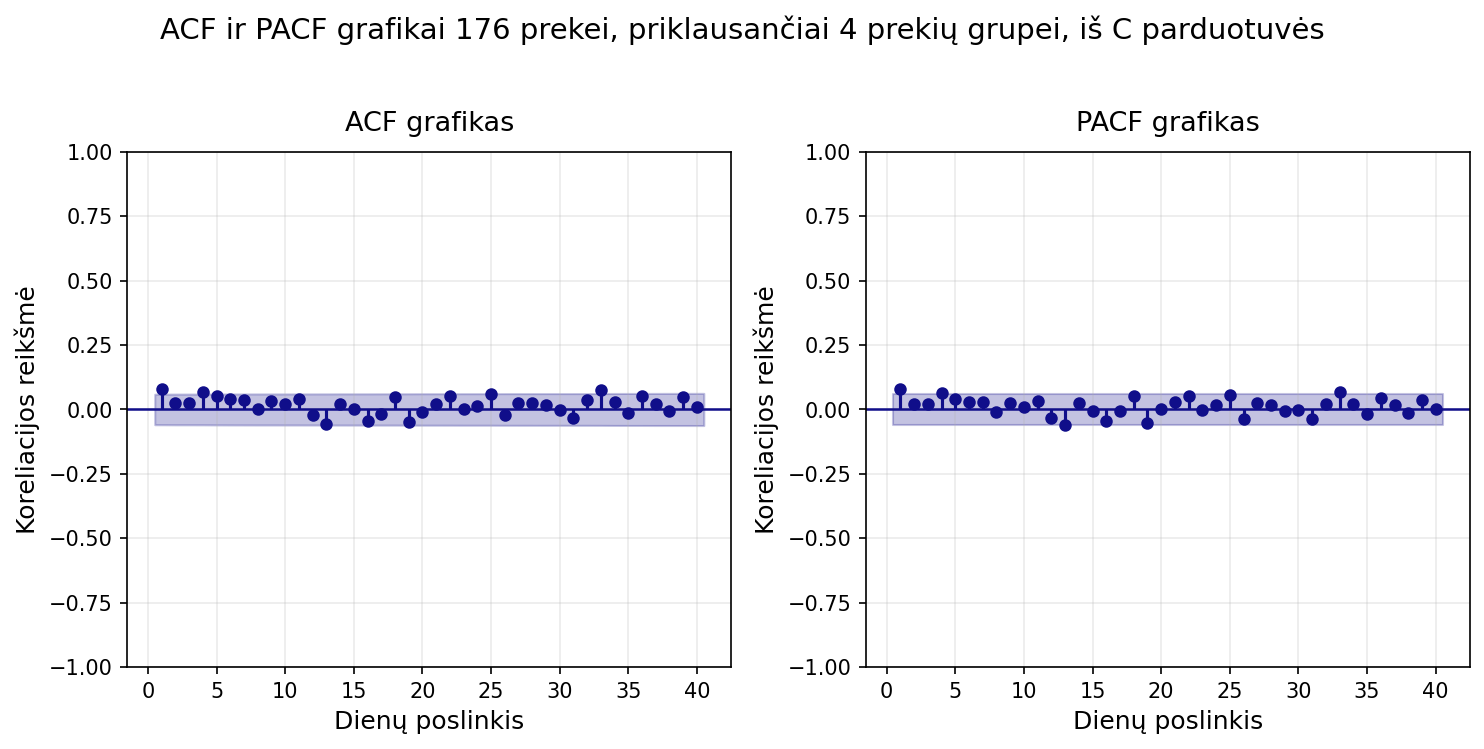

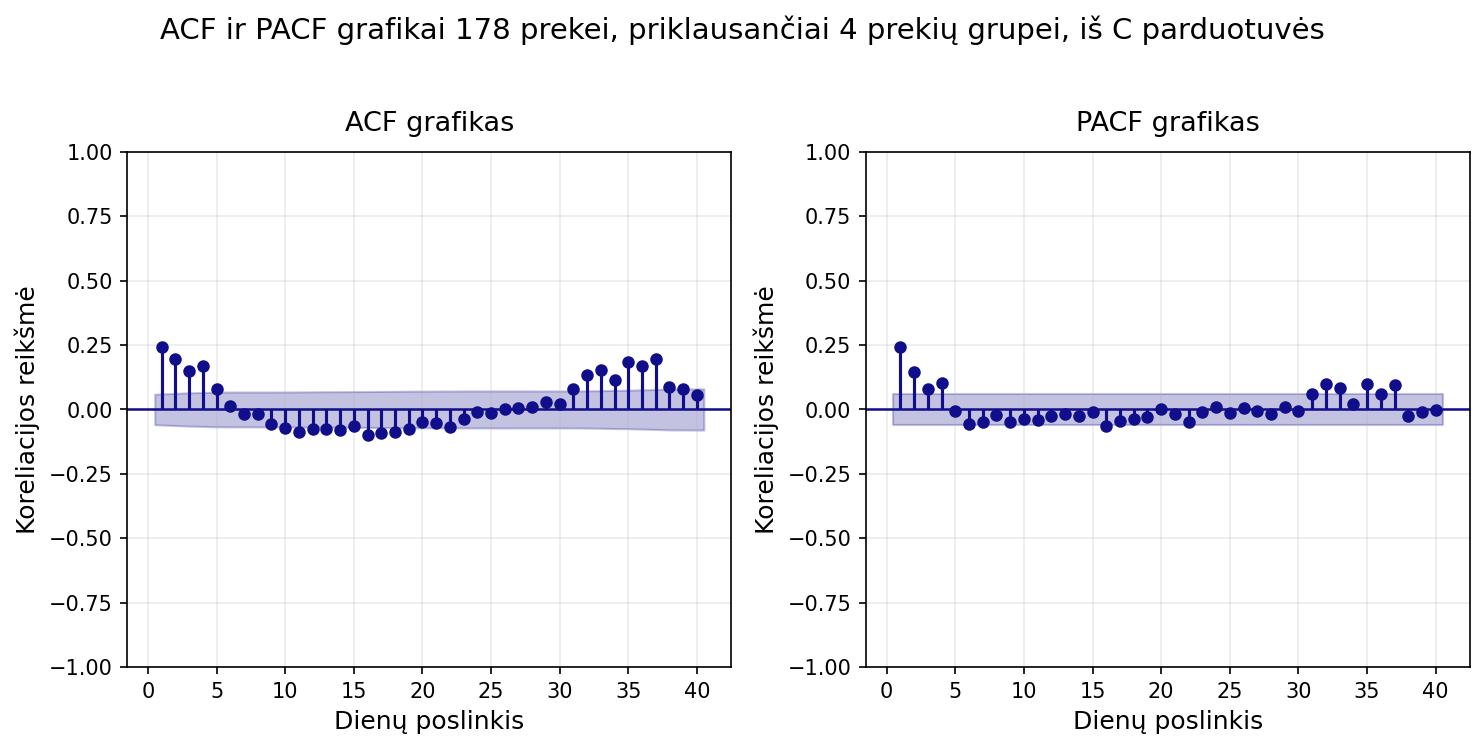

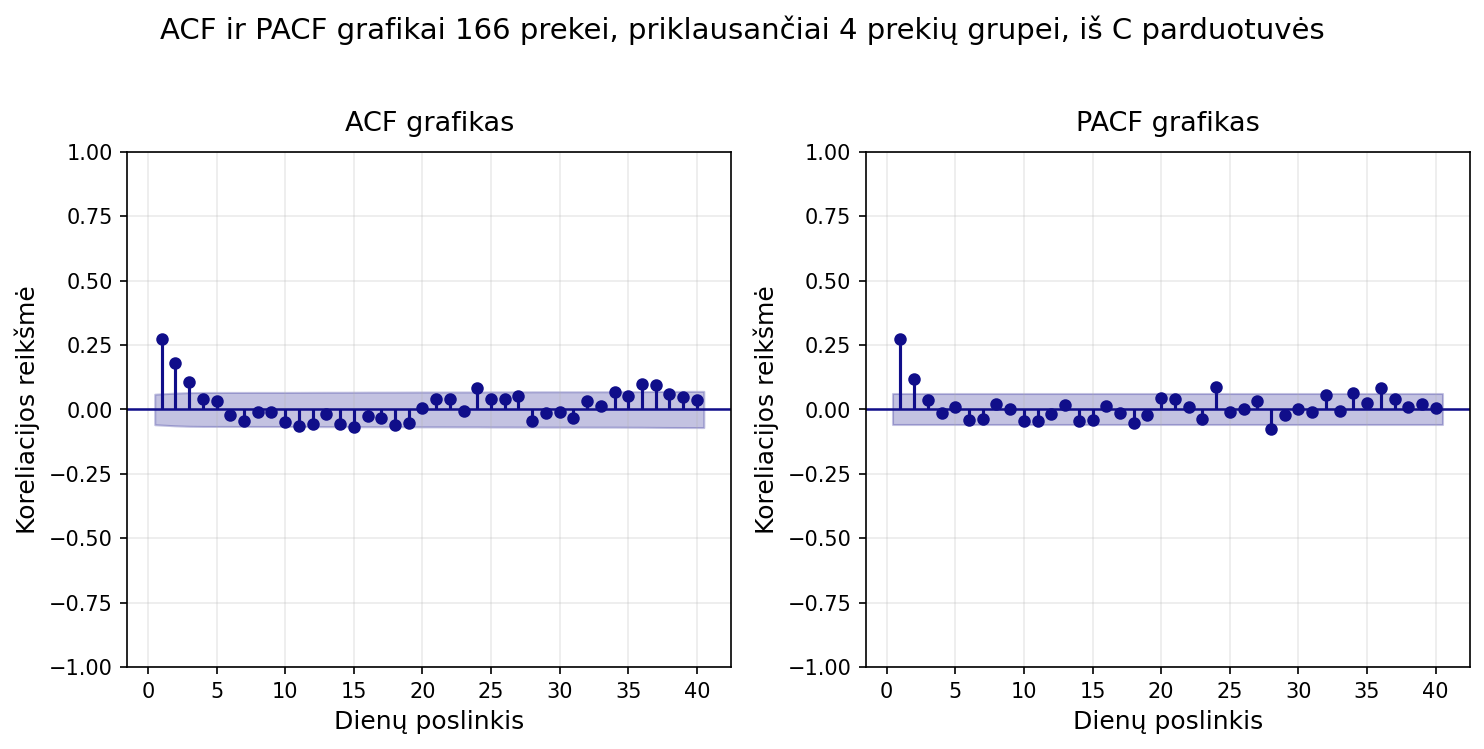

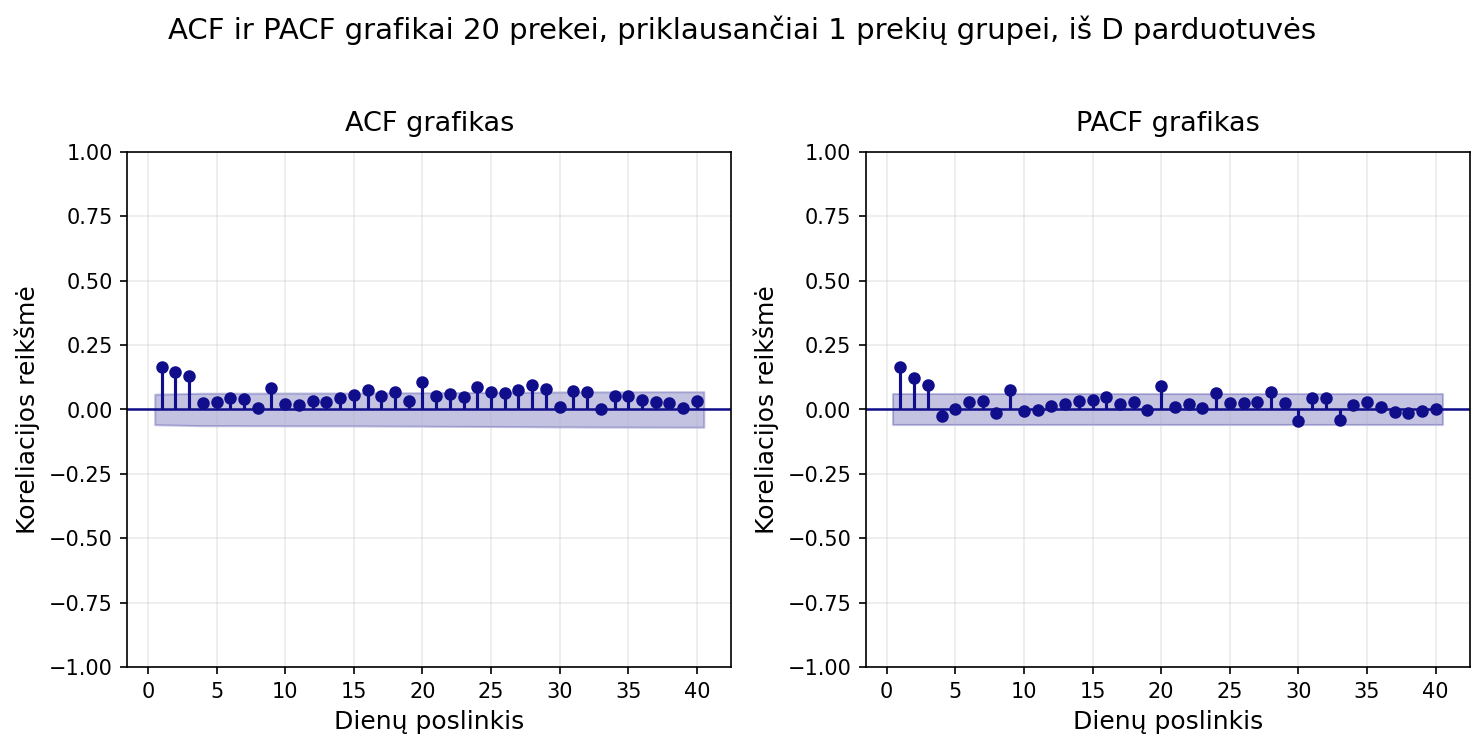

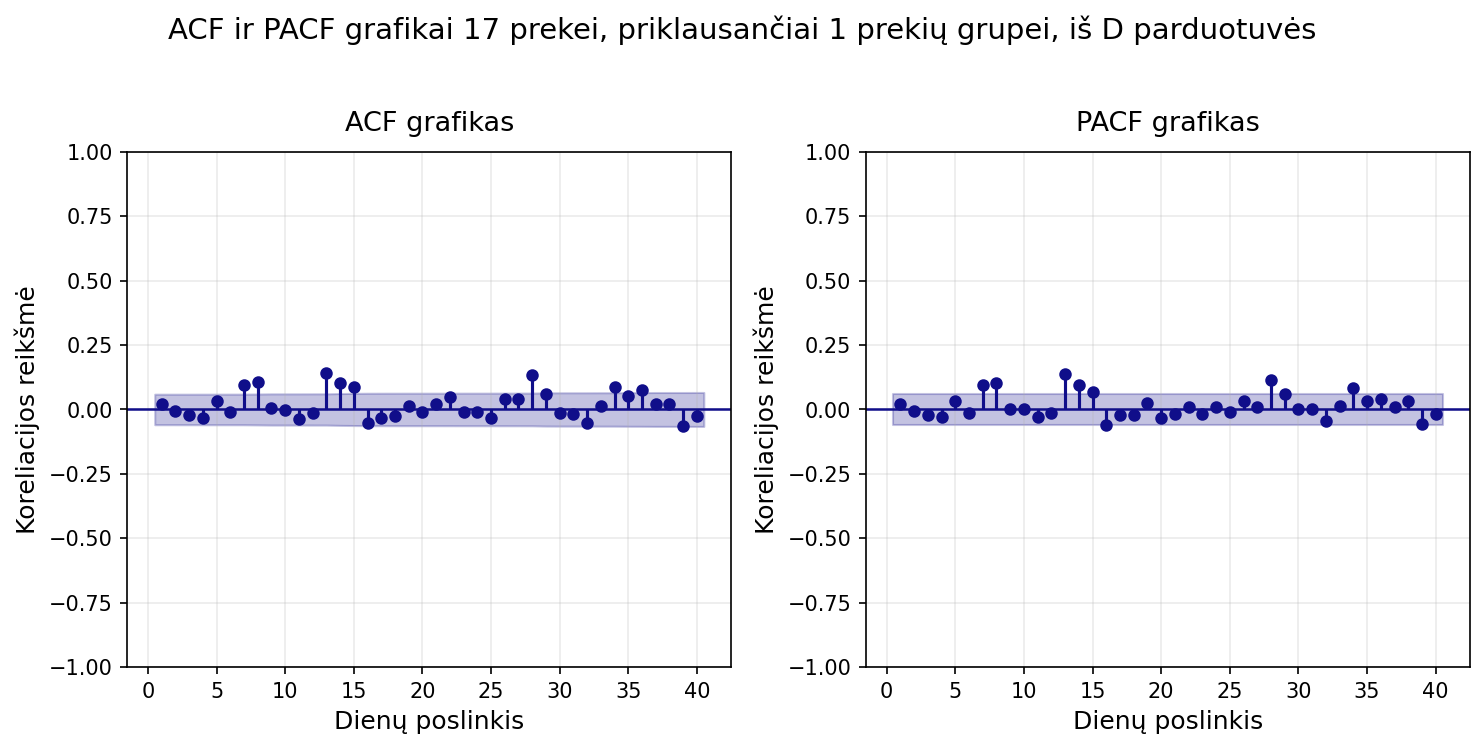

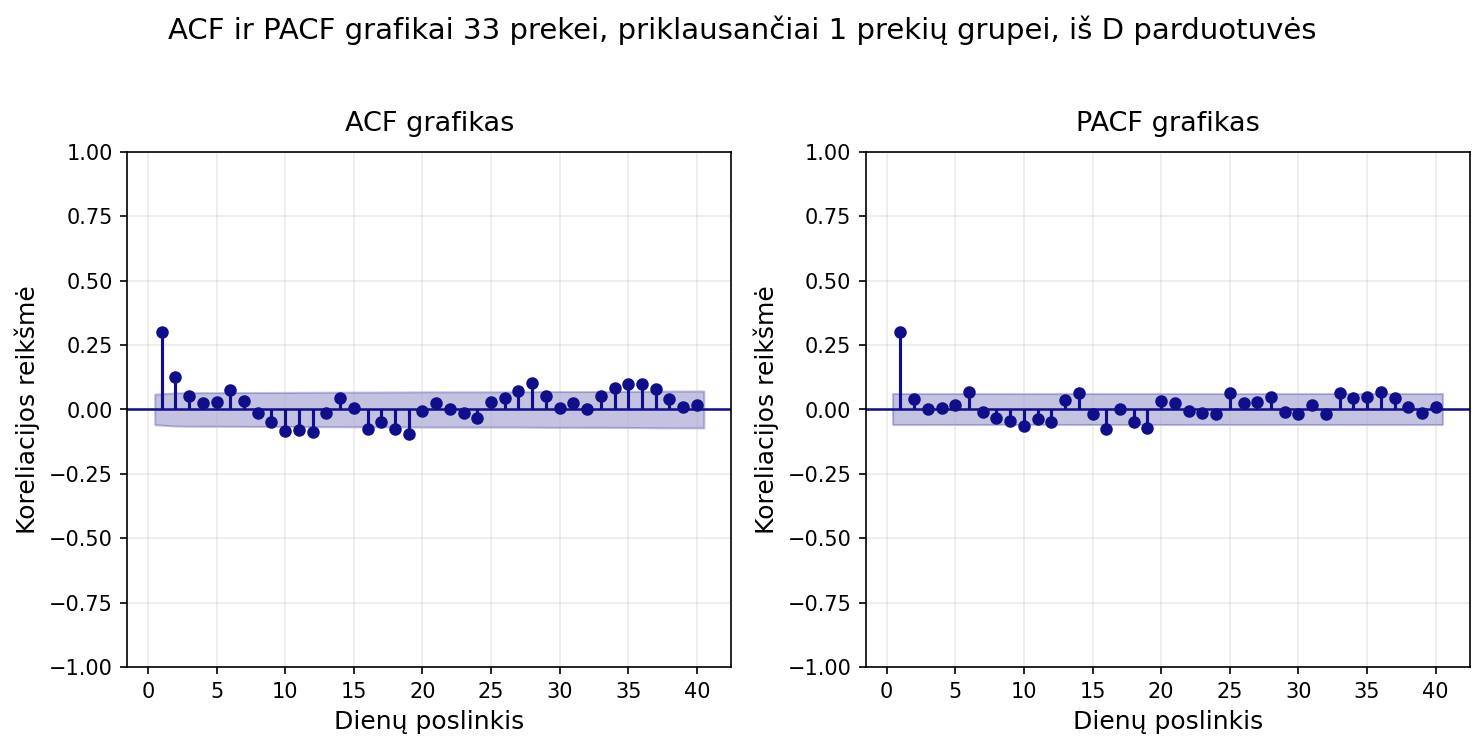

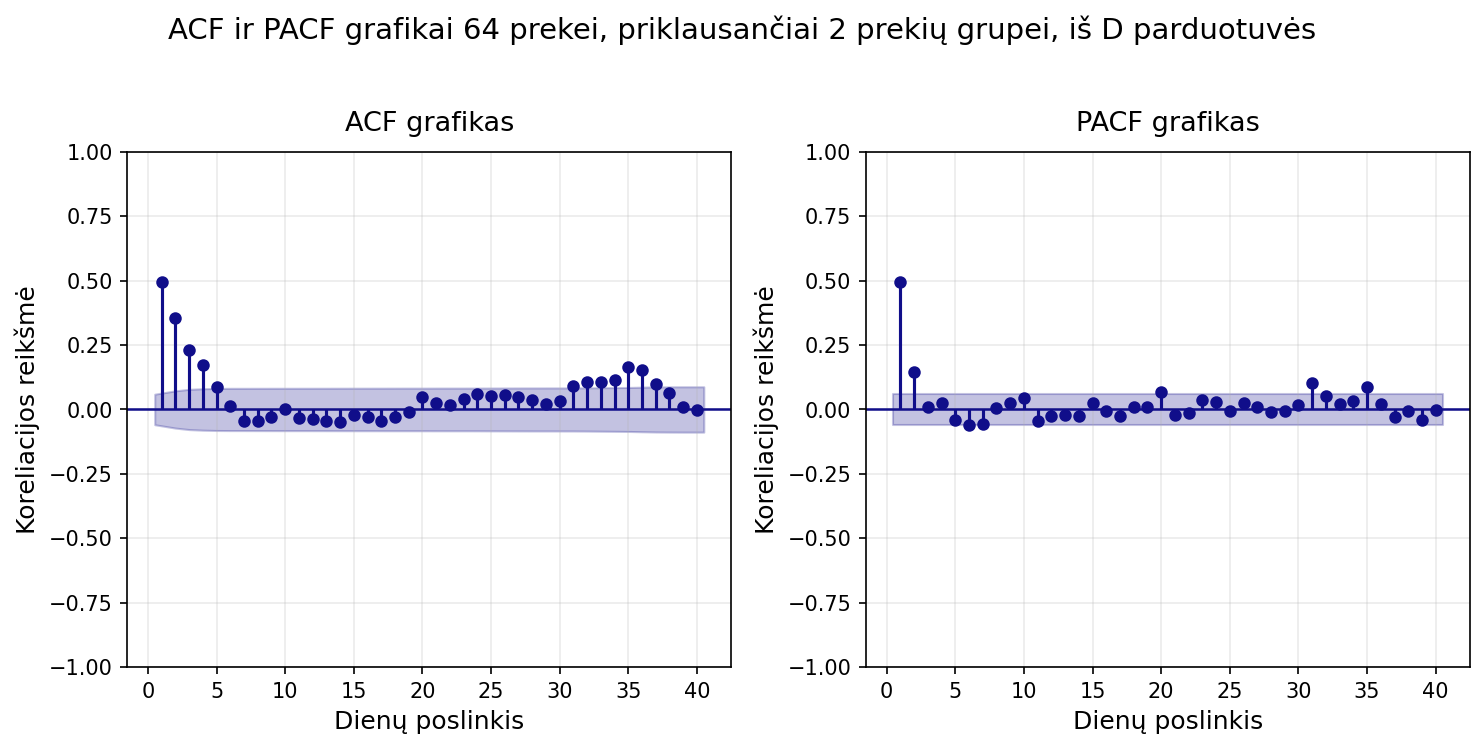

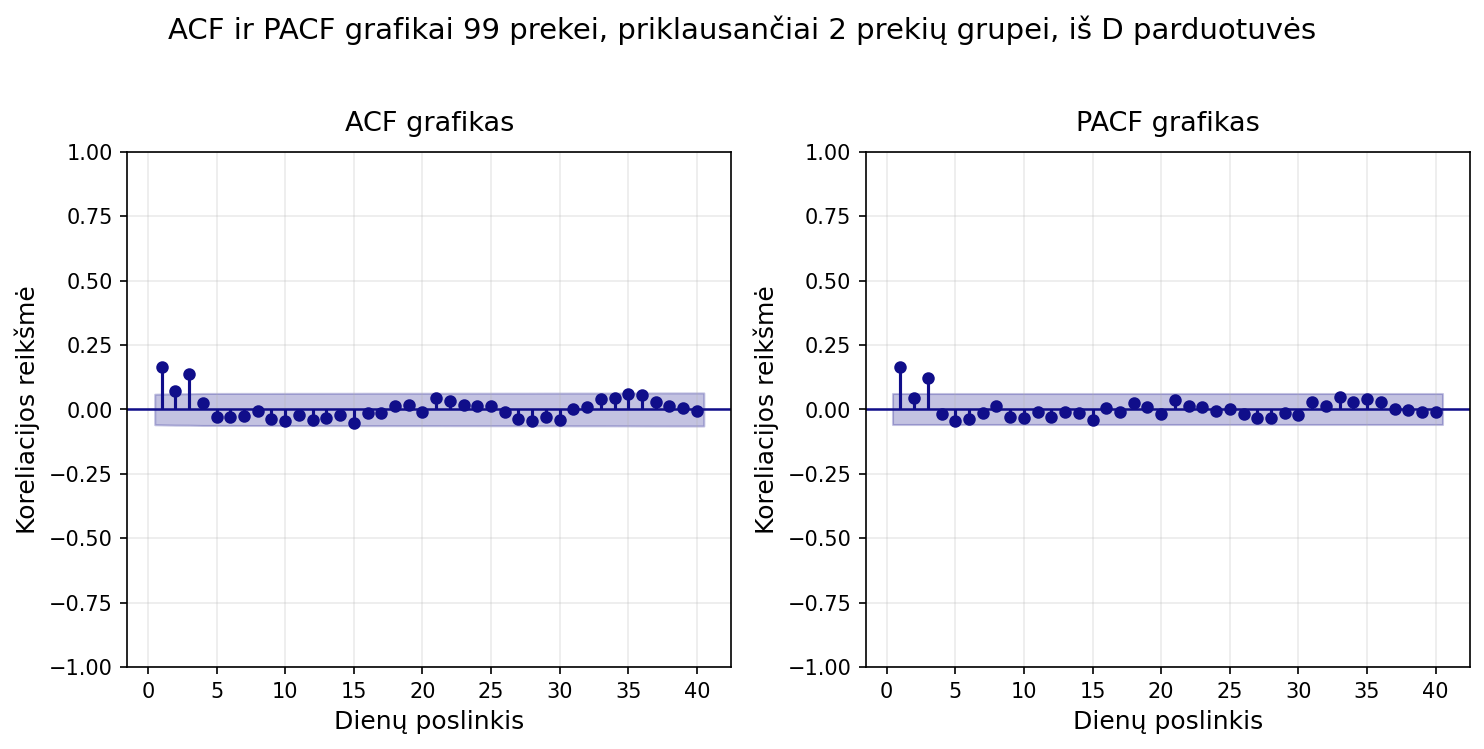

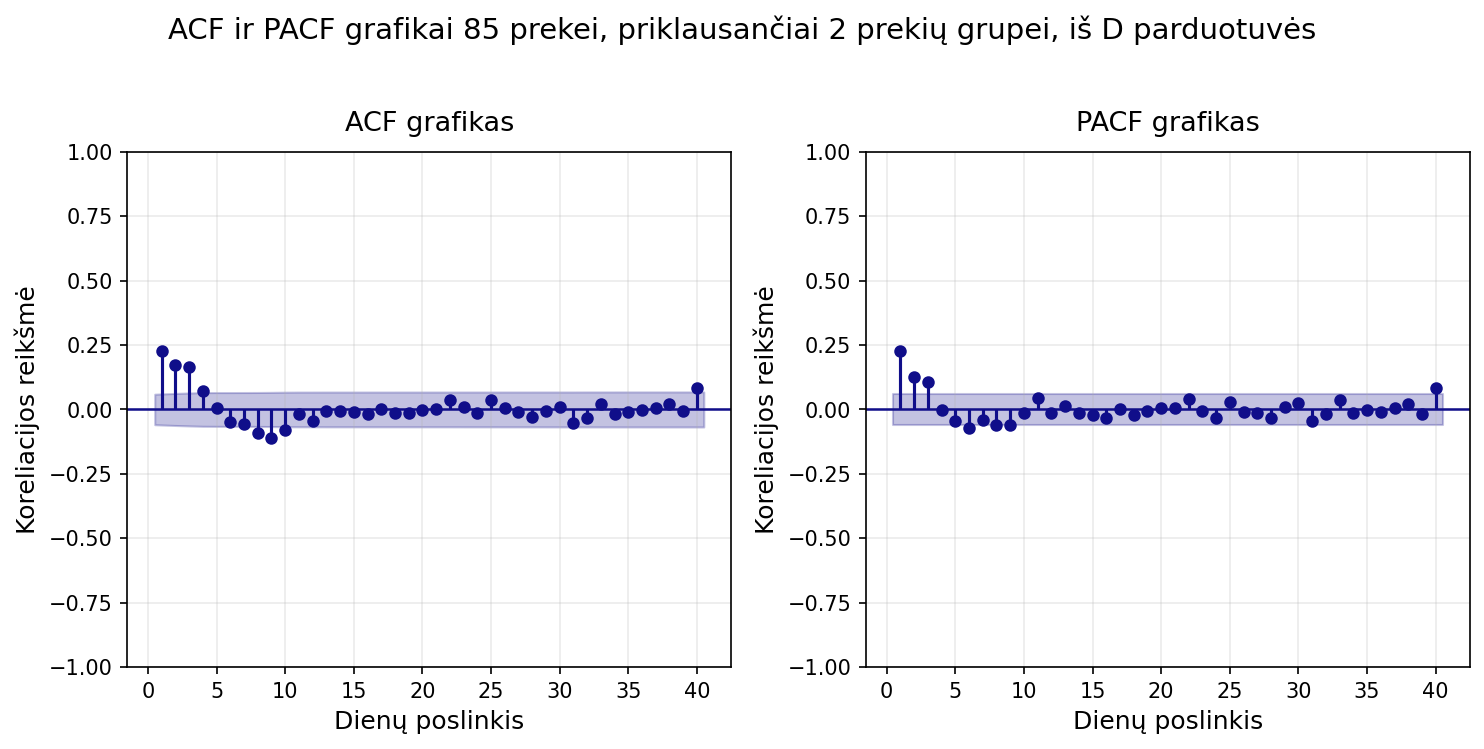

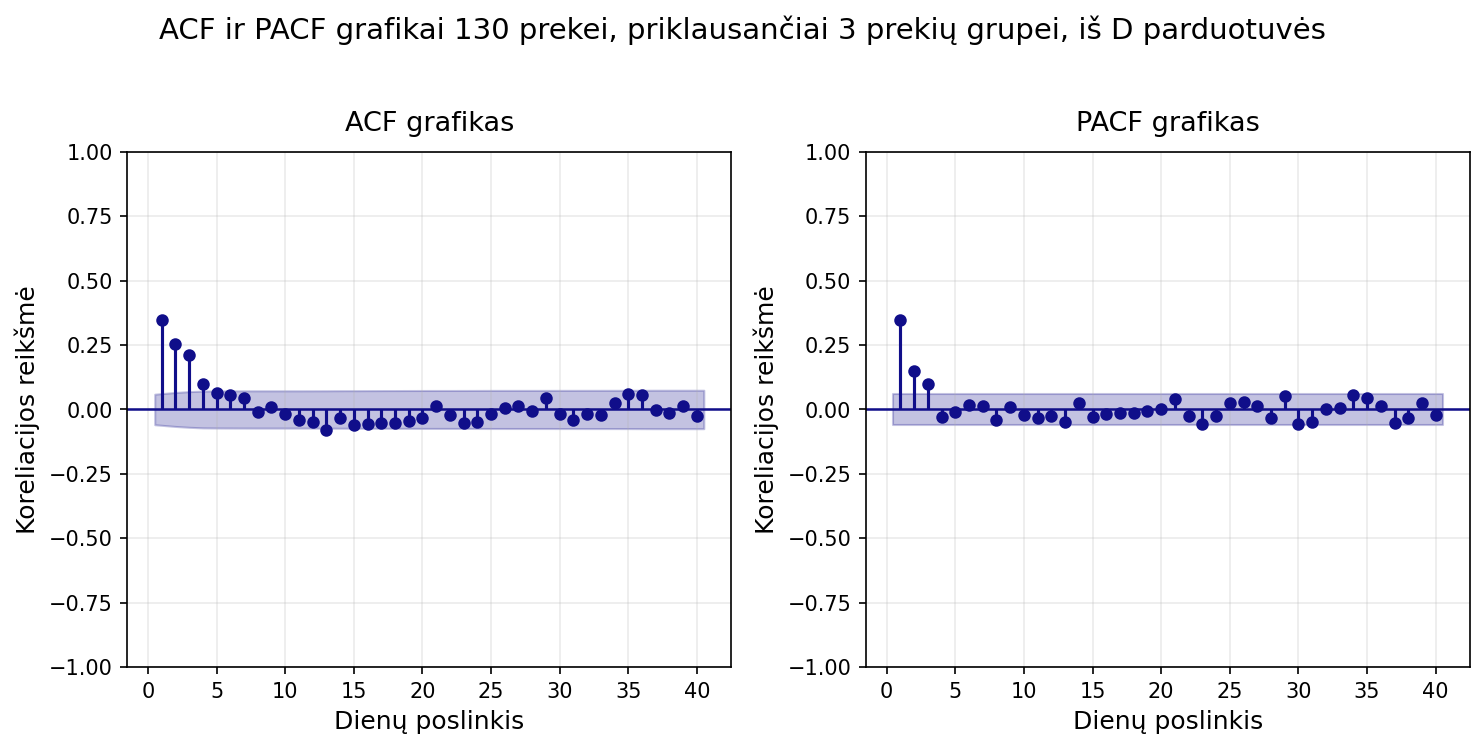

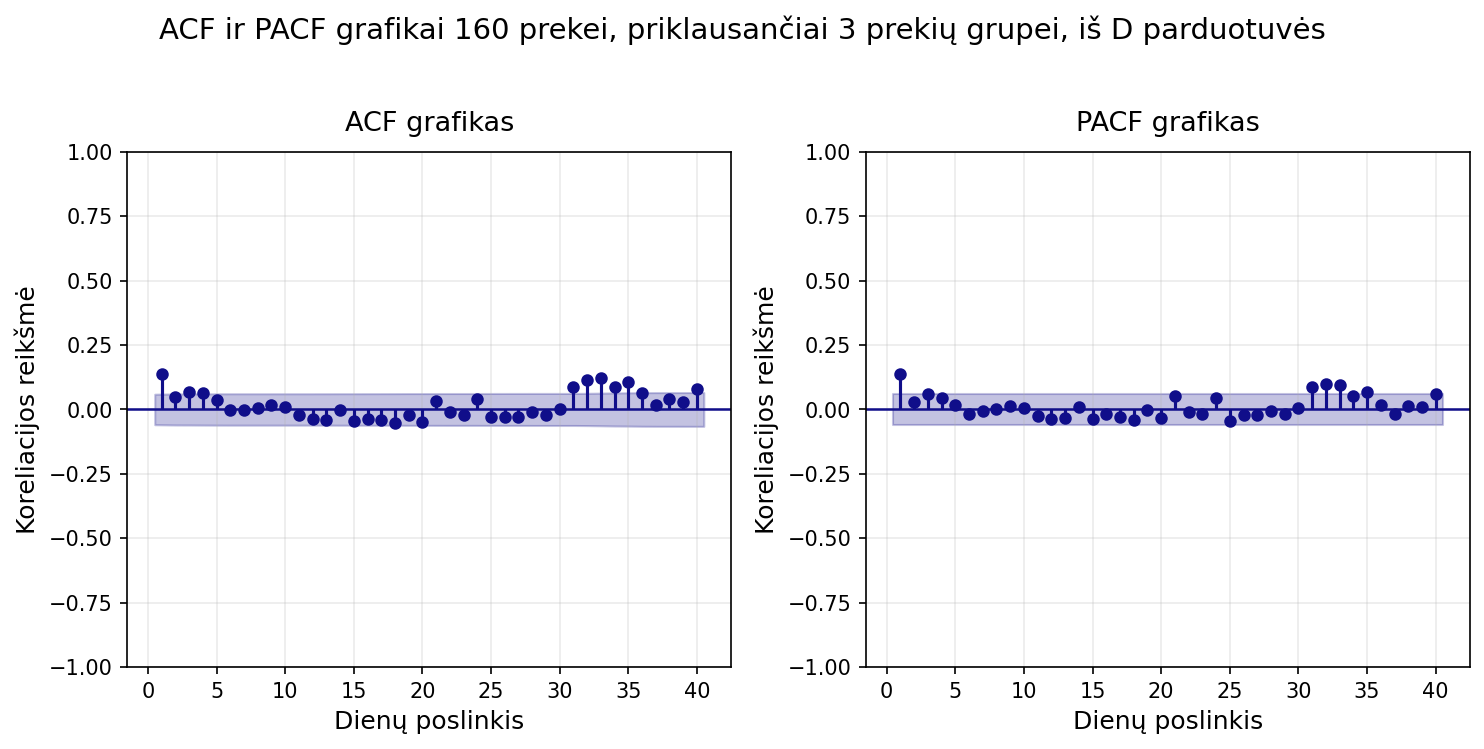

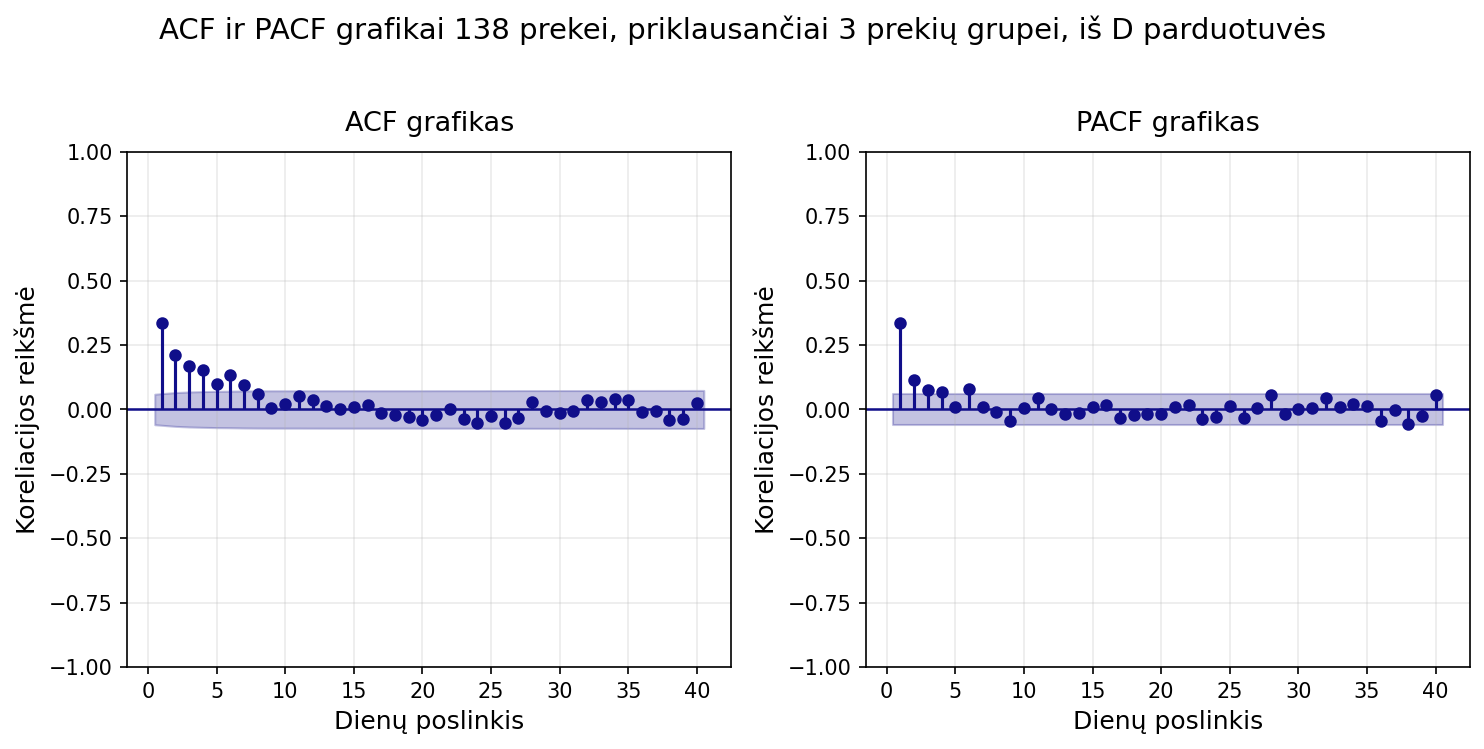

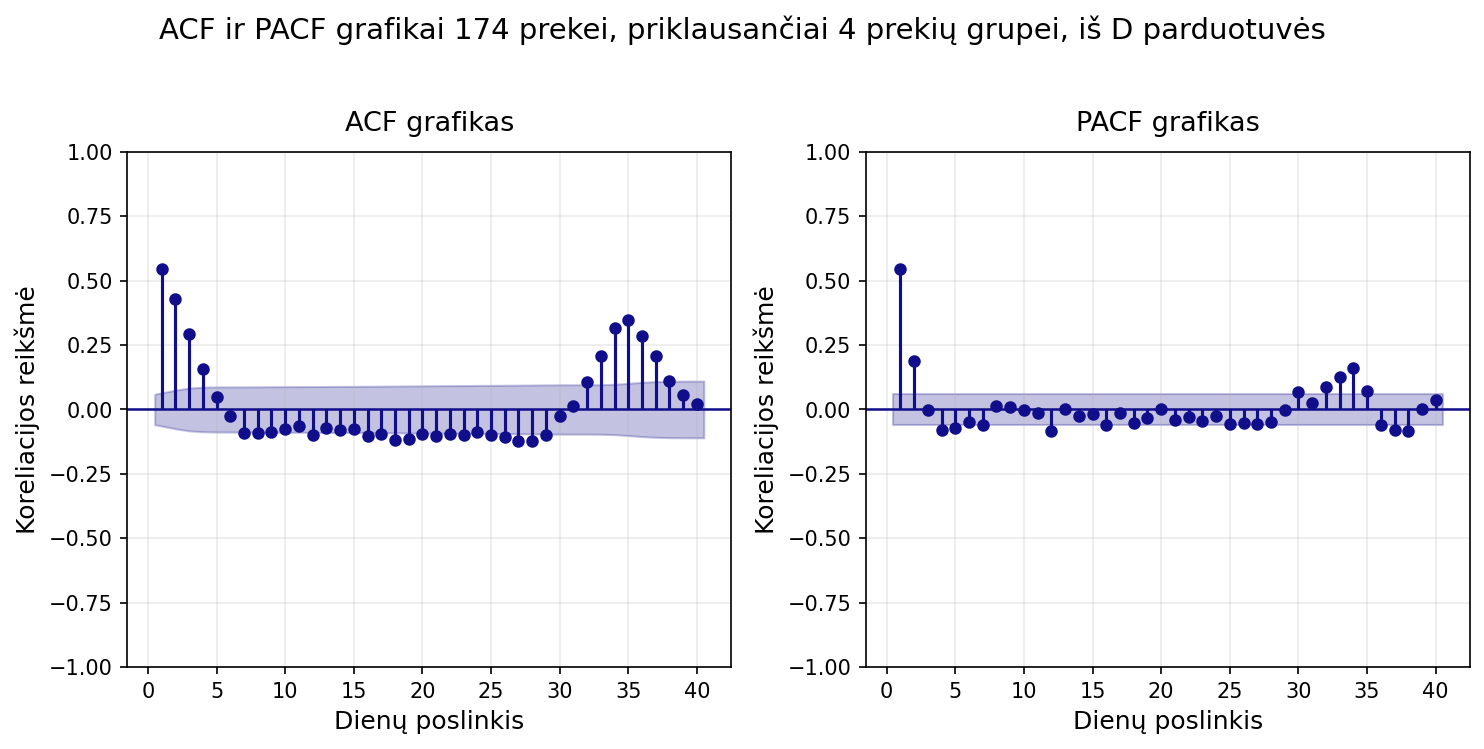

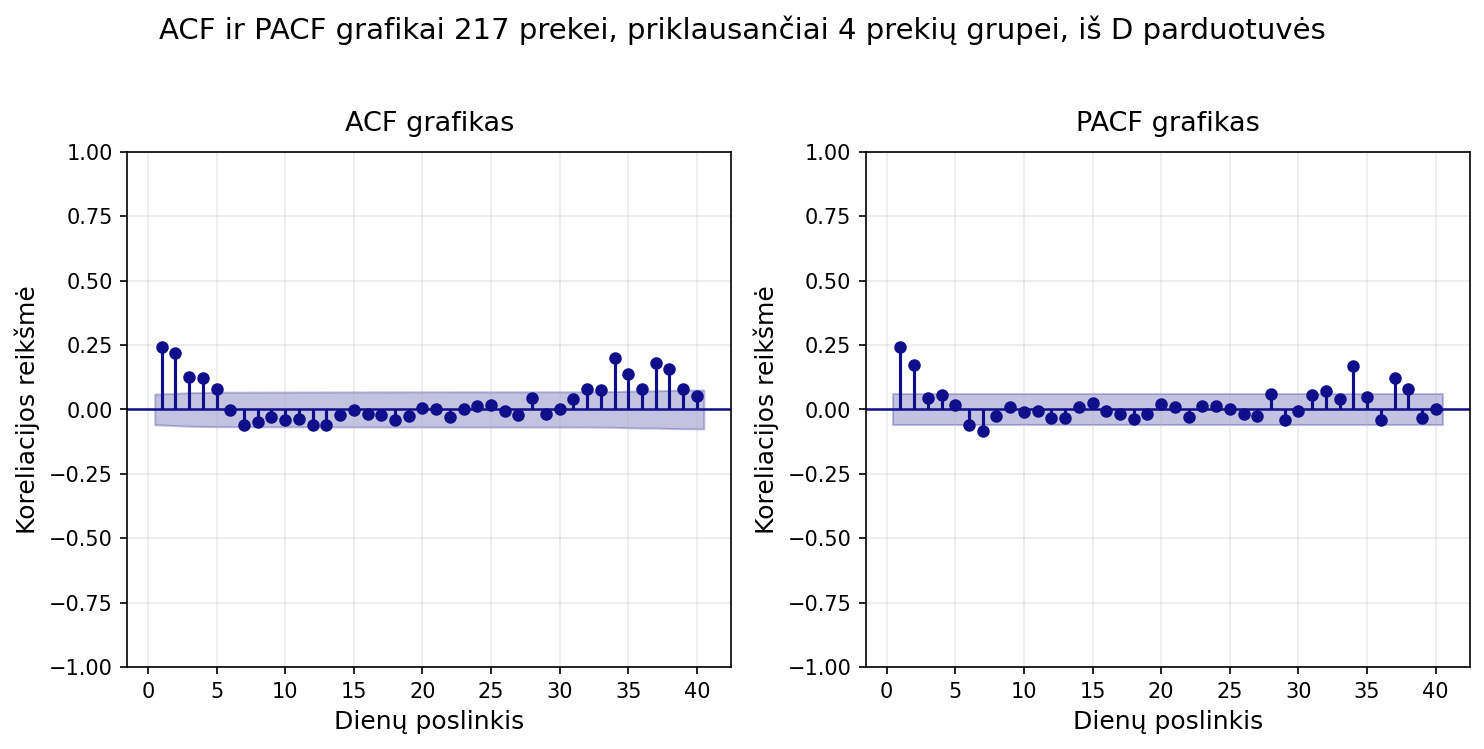

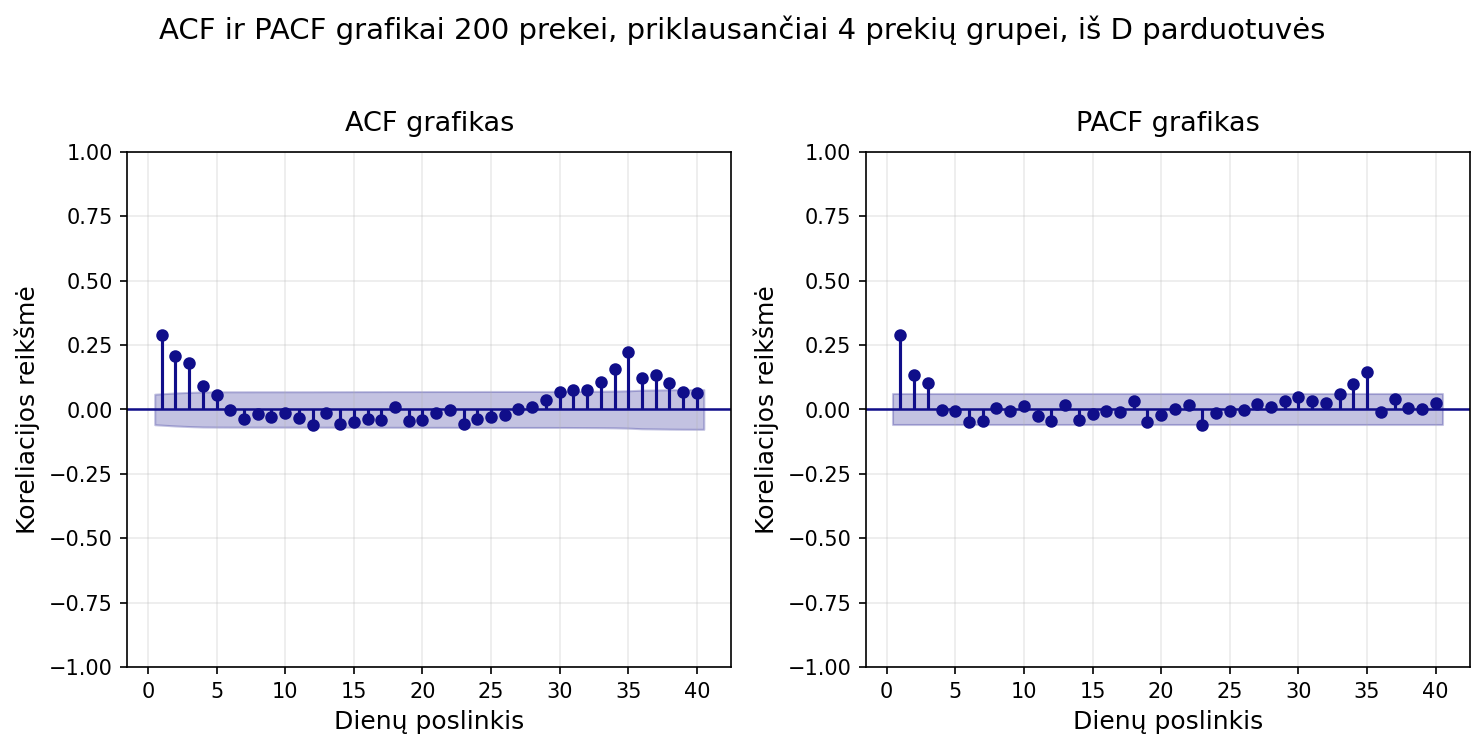

In [8]:
ACF_PACF_LAGS = 40

type_labels_lt = {
    "high_sales_low_zero_pct": "Didelė paklausa",
    "medium_sales_medium_zero_pct": "Vidutinė paklausa",
    "low_sales_high_zero_pct": "Maža paklausa"
}

selected_order = (
    selected_series_metadata
    .sort_values(["STORE_ID", "SKU_GROUP", "series_type_2d", "SKU_ID"])
    ["unique_id"]
    .tolist()
)

for plot_number, unique_id in enumerate(selected_order, start=1):
    meta = selected_series_metadata.loc[
        selected_series_metadata["unique_id"] == unique_id
    ].iloc[0]

    y = (
        main_selected.loc[main_selected["unique_id"] == unique_id]
        .sort_values("DATE")
        .set_index("DATE")
        ["SALES_QTY"]
        .astype(float)
        .dropna()
    )
    lags = min(ACF_PACF_LAGS, len(y) // 2 - 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), dpi=150)
    plot_acf(
        y,
        lags=lags,
        ax=axes[0],
        zero=False
    )
    plot_pacf(
        y,
        lags=lags,
        ax=axes[1],
        zero=False,
        method="ywm"
    )
    demand_type_lt = type_labels_lt.get(
        meta["series_type_2d"],
        str(meta["series_type_2d"])
    )
    fig.suptitle(
        (
            f"ACF ir PACF grafikai {meta['SKU_ID']} prekei, priklausančiai {meta['SKU_GROUP']} prekių grupei, iš {meta['STORE_ID']} parduotuvės"
        ),
        fontsize=14,
        y=1.03
    )
    axes[0].set_title("ACF grafikas", fontsize=13, pad=10)
    axes[1].set_title("PACF grafikas", fontsize=13, pad=10)
    for ax in axes:
        ax.set_xlabel("Dienų poslinkis", fontsize=12)
        ax.set_ylabel("Koreliacijos reikšmė", fontsize=12)
        ax.tick_params(axis="both", labelsize=10)
        ax.grid(alpha=0.25)
        for line in ax.lines:
            line.set_color("#100E8A")
            line.set_linewidth(1.2)
        for coll in ax.collections:
            try:
                coll.set_color("#100E8A")
            except:
                pass
    plt.tight_layout()
    plt.show()
    plt.close(fig)